In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Показывать все строки
pd.set_option('display.max_columns', None)  # Показывать все столбцы

import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats 

### Import Dataset

In [2]:
# ипортируем датасет, отбросим переменную 'Id', проведем индексацию с 1.
data = (pd.read_csv('../houseprice.csv')).drop('Id', axis=1).shift()[1:]
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1,60.0,RL,65.0,8450.0,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5.0,2003.0,2003.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856.0,854.0,0.0,1710.0,1.0,0.0,2.0,1.0,3.0,1.0,Gd,8.0,Typ,0.0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0.0,61.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2008.0,WD,Normal,208500.0
2,20.0,RL,80.0,9600.0,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6.0,8.0,1976.0,1976.0,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262.0,0.0,0.0,1262.0,0.0,1.0,2.0,0.0,3.0,1.0,TA,6.0,Typ,1.0,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,5.0,2007.0,WD,Normal,181500.0
3,60.0,RL,68.0,11250.0,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5.0,2001.0,2002.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920.0,866.0,0.0,1786.0,1.0,0.0,2.0,1.0,3.0,1.0,Gd,6.0,Typ,1.0,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0.0,42.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,9.0,2008.0,WD,Normal,223500.0
4,70.0,RL,60.0,9550.0,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7.0,5.0,1915.0,1970.0,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961.0,756.0,0.0,1717.0,1.0,0.0,1.0,0.0,3.0,1.0,Gd,7.0,Typ,1.0,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0.0,35.0,272.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2006.0,WD,Abnorml,140000.0
5,60.0,RL,84.0,14260.0,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8.0,5.0,2000.0,2000.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145.0,1053.0,0.0,2198.0,1.0,0.0,2.0,1.0,4.0,1.0,Gd,9.0,Typ,1.0,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192.0,84.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,12.0,2008.0,WD,Normal,250000.0


In [3]:
# посмотрим ключевые статистические характеристики таргета
data['SalePrice'].describe()

count      1459.000000
mean     180944.102810
std       79464.918335
min       34900.000000
25%      129950.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

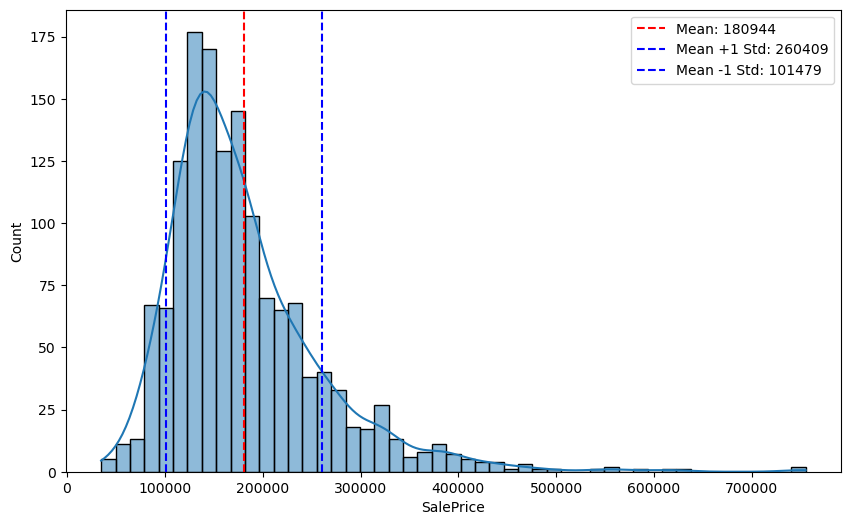

In [4]:
# отрисовка распределения цены.
plt.figure(figsize=(10, 6))
sns.histplot(data['SalePrice'], kde=True, edgecolor='black')

mean_price = data["SalePrice"].mean()
std_price = data["SalePrice"].std()

plt.axvline(mean_price, color="red", linestyle="--", label=f"Mean: {mean_price:.0f}")
plt.axvline(mean_price + std_price, color="blue", linestyle="--", label=f"Mean +1 Std: {mean_price + std_price:.0f}")
plt.axvline(mean_price - std_price, color="blue", linestyle="--", label=f"Mean -1 Std: {mean_price - std_price:.0f}")
plt.legend()
plt.show()

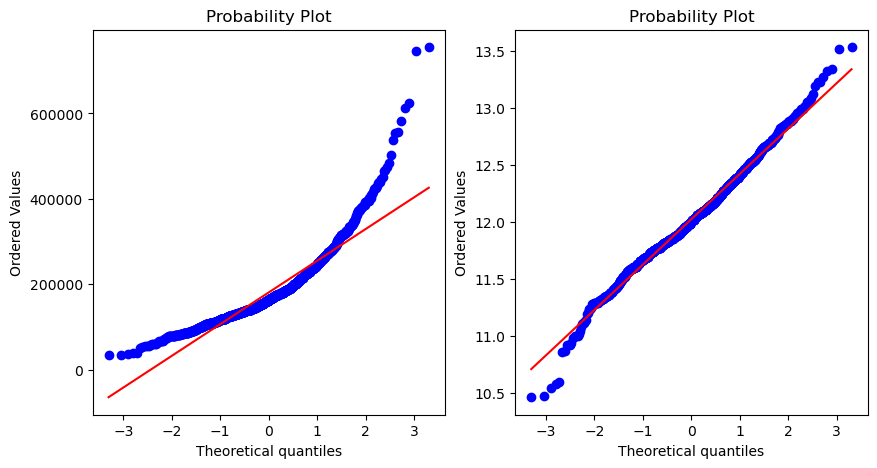

In [5]:
# Оценка нормальности данных
fig = plt.figure(figsize = (10,5))

# Распределение оригинала
fig.add_subplot(1,2,1)
res = stats.probplot(data['SalePrice'], plot=plt)

# Распределение при логарифмировании 'SalePrice'
fig.add_subplot(1,2,2)
res = stats.probplot(np.log1p(data['SalePrice']), plot=plt)

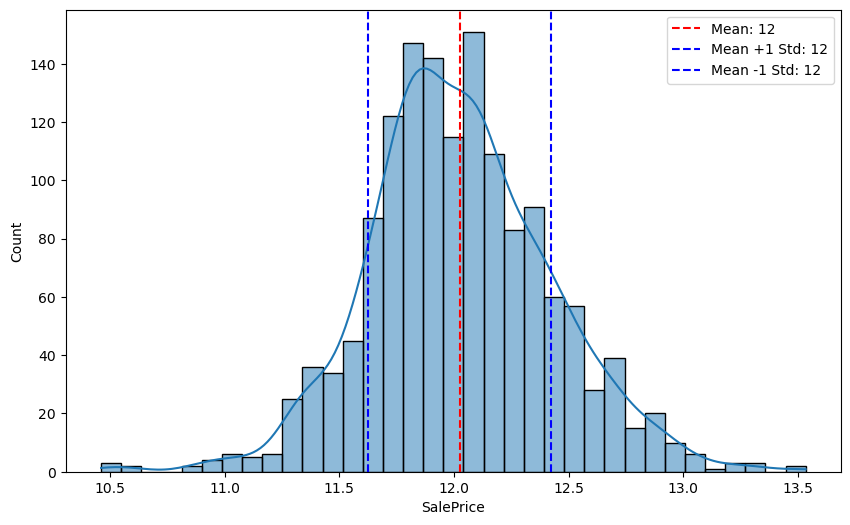

In [6]:
# отрисовка распределения цены.
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(data['SalePrice']), kde=True, edgecolor='black')

mean_price = np.log1p(data['SalePrice']).mean()
std_price = np.log1p(data['SalePrice']).std()

plt.axvline(mean_price, color="red", linestyle="--", label=f"Mean: {mean_price:.0f}")
plt.axvline(mean_price + std_price, color="blue", linestyle="--", label=f"Mean +1 Std: {mean_price + std_price:.0f}")
plt.axvline(mean_price - std_price, color="blue", linestyle="--", label=f"Mean -1 Std: {mean_price - std_price:.0f}")
plt.legend()
plt.show()

In [7]:
# определим категориальные признаки
categorical = data.select_dtypes(include=['object', 'category']).columns
categorical

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [8]:
# переопределим датасет, используя только призаки категорий.
data_categorical = (pd.read_csv('../houseprice.csv', usecols=categorical.append(pd.Index(['SalePrice'])))).shift()[1:]
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1,60.0,RL,65.0,8450.0,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5.0,2003.0,2003.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856.0,854.0,0.0,1710.0,1.0,0.0,2.0,1.0,3.0,1.0,Gd,8.0,Typ,0.0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0.0,61.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2008.0,WD,Normal,208500.0
2,20.0,RL,80.0,9600.0,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6.0,8.0,1976.0,1976.0,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262.0,0.0,0.0,1262.0,0.0,1.0,2.0,0.0,3.0,1.0,TA,6.0,Typ,1.0,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,5.0,2007.0,WD,Normal,181500.0
3,60.0,RL,68.0,11250.0,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7.0,5.0,2001.0,2002.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920.0,866.0,0.0,1786.0,1.0,0.0,2.0,1.0,3.0,1.0,Gd,6.0,Typ,1.0,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0.0,42.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,9.0,2008.0,WD,Normal,223500.0
4,70.0,RL,60.0,9550.0,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7.0,5.0,1915.0,1970.0,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961.0,756.0,0.0,1717.0,1.0,0.0,1.0,0.0,3.0,1.0,Gd,7.0,Typ,1.0,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0.0,35.0,272.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2006.0,WD,Abnorml,140000.0
5,60.0,RL,84.0,14260.0,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8.0,5.0,2000.0,2000.0,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145.0,1053.0,0.0,2198.0,1.0,0.0,2.0,1.0,4.0,1.0,Gd,9.0,Typ,1.0,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192.0,84.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,12.0,2008.0,WD,Normal,250000.0


In [9]:
data_categorical.shape

(1459, 44)

### Missing values

In [10]:
missing_data = (pd.concat([data_categorical.isnull().sum(), data_categorical.isna().mean() * 100], keys = ['count','%'], axis = 1)).sort_values(ascending=False, by='count')
missing_data = missing_data[missing_data['count'] > 0]
missing_data

,count,%
PoolQC,1452,99.520219
MiscFeature,1405,96.298835
Alley,1368,93.762851
Fence,1178,80.740233
MasVnrType,871,59.698424
FireplaceQu,689,47.224126
GarageType,81,5.551748
GarageQual,81,5.551748
GarageCond,81,5.551748
GarageFinish,81,5.551748


После проведения анализа природы появления пустых значений, было установлено что отсутвие значения не что иное как отсутствие данной опции в доме.

Отчетливо видно в признаках отражающих схожую характеристику (пр. GarageType, GarageQual, GarageCond, GarageFinish).

В следствии чего принято решение заменить пропущеные значения на лейбл 'no_option', т.к. переменная может нести в себе информацию и влиять на конечную стоимость дома.

В последуюшем будет учтено, что такие признаки как 'FirePLaceQU, GarageQual, BsmntQual' несут в себе информацию о качестве и при кодировке будут отражать уровень, значение 'no_option' будет соответсвовать уровню '0', либо уже имеющемуся уровню 1 в соответсвии с кол-м и ср. ценой.

Text(0.5, 1.0, 'No option')

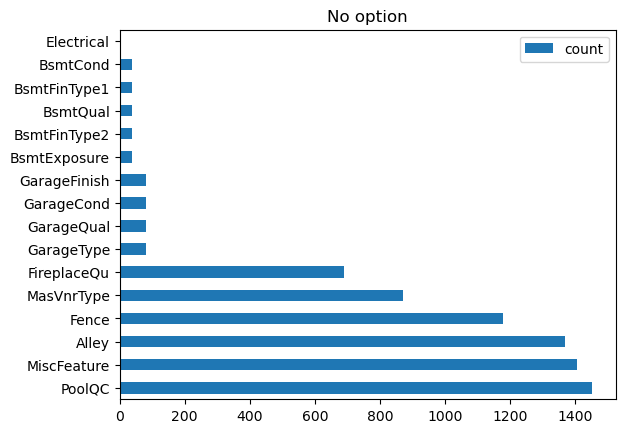

In [11]:
missing_data.drop(['%'], axis=1).plot.barh().set_title('No option')

In [120]:
# восстановим отсутствующие значения в датасете для анализа.
data_categorical.fillna("no_option", inplace=True)

### Проведем визуальный анализ признаков, и проведем отбор на основе графиков.

In [14]:
# функция средних значений кол-ва, процента домов и средней стоимости по категориям в признаке.
def calculate_mean_target_per_category(df, var):
    total_houses = len(df)

    # количеством домов и процента
    temp_df = pd.DataFrame(df[var].value_counts()).reset_index()
    temp_df.columns = [var, 'count_houses']

    # Добавляем процентное соотношение
    temp_df['perc_houses'] = (temp_df['count_houses'] / total_houses)

    # Добавляем среднюю цену `SalePrice` для каждой категории
    temp_df = temp_df.merge(
        df.groupby([var])['SalePrice'].mean().reset_index(),
        on=var,
        how='left'
    )

    return temp_df

In [15]:
# функция отрисовки
def plot_categories(df, var):
    fig, ax = plt.subplots(figsize = (6,3))
    plt.xticks(df.index, df[var], rotation = 90)

    ax2 = ax.twinx()
    ax.bar(df.index, df['perc_houses'], color = 'lightgrey')
    ax2.plot(df.index, df['SalePrice'], color = 'green', label = 'Second')
    ax.axhline(y = 0.05, color = 'red')
    ax.set_ylabel('Percentage of houses per category')
    ax.set_xlabel(var)
    ax2.set_ylabel('Average Sale price per category')
    plt.show()

In [16]:
# функция отрисовки графика переменной
def feature_to_look(col):
    temp_df = calculate_mean_target_per_category(data_categorical, col)
    print(temp_df)
    print()
    print(f'{(data_categorical[col].isna().mean() * 100).round(2)}% - missing value.')
    sns.boxplot(x=col, y='SalePrice', data=data_categorical)
    plot_categories(temp_df, col)

  MSZoning  count_houses  perc_houses      SalePrice
0       RL          1150     0.788211  191042.825217
1       RM           218     0.149417  126316.830275
2       FV            65     0.044551  214014.061538
3       RH            16     0.010966  131558.375000
4  C (all)            10     0.006854   74528.000000

0.0% - missing value.


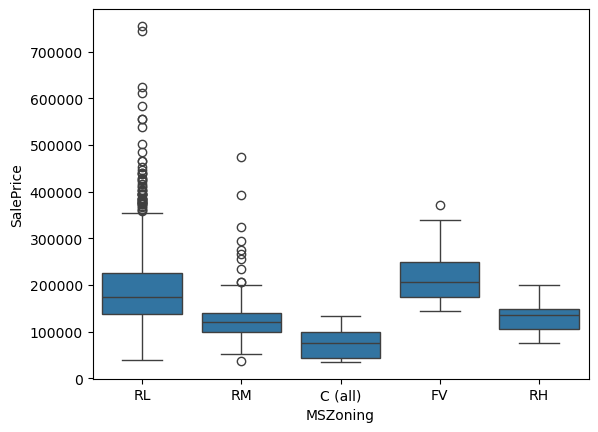

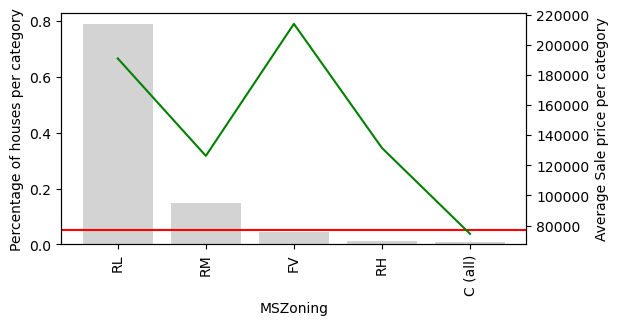

In [17]:
feature_to_look('MSZoning')

Зонирование участка напрямую влияет на возможности его использования, что в свою очередь может значительно повлиять на конечную стоимость.

Чёткая разница в средних и медианах цен по категориям.

Более 90% домов в категориях:
- RL низкая плотность застройки 
- RM средняя плотность
При этом наблюдается значимое снижение цены при росте плотности.

RH высокая плотность имеет схожие параметры со средней. Можно объединить.

  Street  count_houses  perc_houses      SalePrice
0   Pave          1453     0.995888  181153.684102
1   Grvl             6     0.004112  130190.500000

0.0% - missing value.


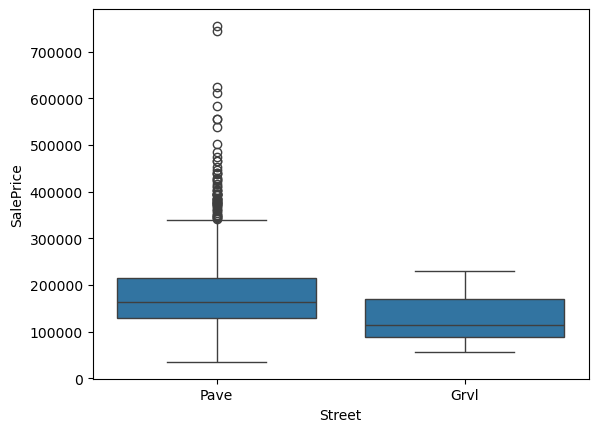

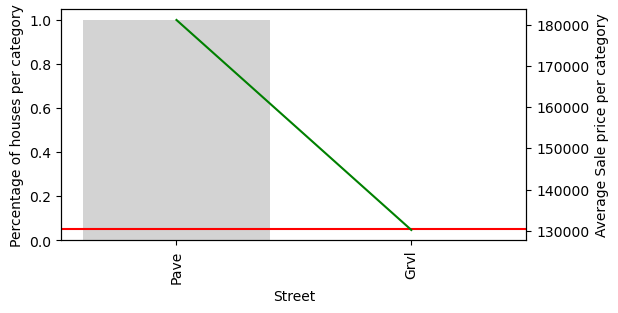

In [18]:
feature_to_look('Street')

В данном случае наблюдается доминация асфальтового типа покрытия над гравием.

У более че 99% домов улица асфальтирована. Признак имеет незначительное влияние на таргет.

       Alley  count_houses  perc_houses      SalePrice
0  no_option          1368     0.937629  183478.412281
1       Grvl            50     0.034270  122219.080000
2       Pave            41     0.028101  168000.585366

0.0% - missing value.


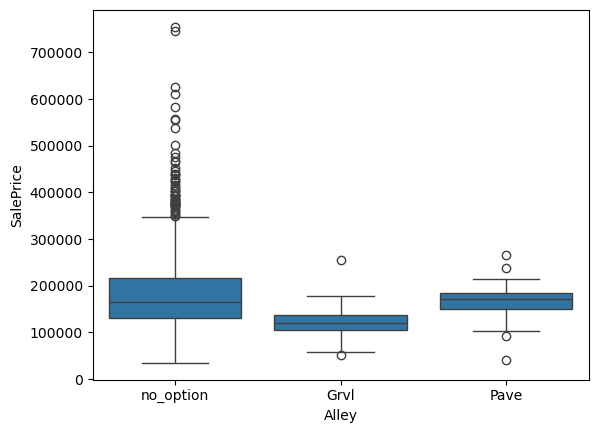

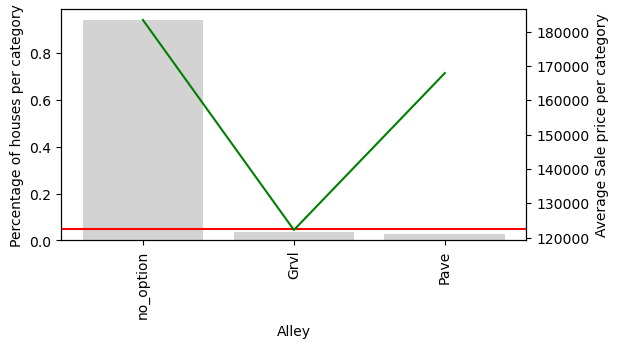

In [19]:
feature_to_look('Alley')

Доступ к переулку имеет низкое влияние на таргет, т.к. 94% домов не юмеют данной опции.

При этом дома с остуствием доступа могут быть и дешевыми и дорогими.

  LotShape  count_houses  perc_houses      SalePrice
0      Reg           924     0.633310  164773.492424
1      IR1           484     0.331734  206101.665289
2      IR2            41     0.028101  239833.365854
3      IR3            10     0.006854  216036.500000

0.0% - missing value.


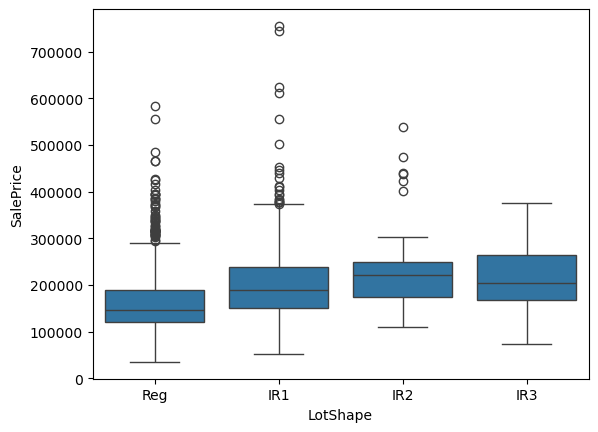

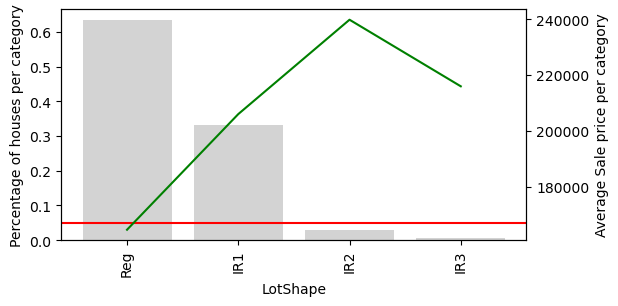

In [20]:
feature_to_look('LotShape')

Более крутой уклон снижает цену, но не критично.

63% домов имеют правильную форму, при этом низкую цену.

Например в районах с дорогой недвижимостью даже участки с сильным уклоном могут оставаться привлекательными.

Потенциально незначительное влияние на цену.


  LandContour  count_houses  perc_houses      SalePrice
0         Lvl          1310     0.897875  180208.696183
1         Bnk            63     0.043180  143104.079365
2         HLS            50     0.034270  231533.940000
3         Low            36     0.024674  203661.111111

0.0% - missing value.


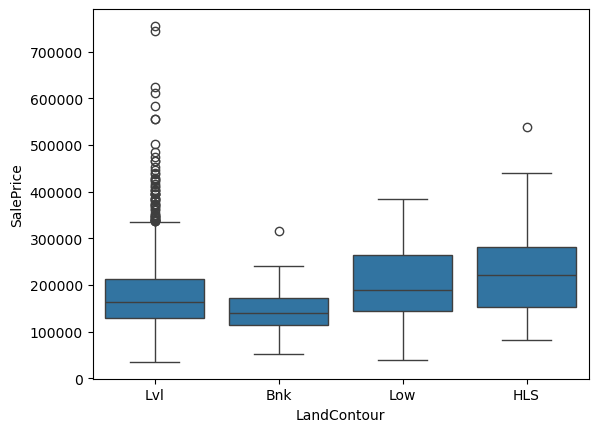

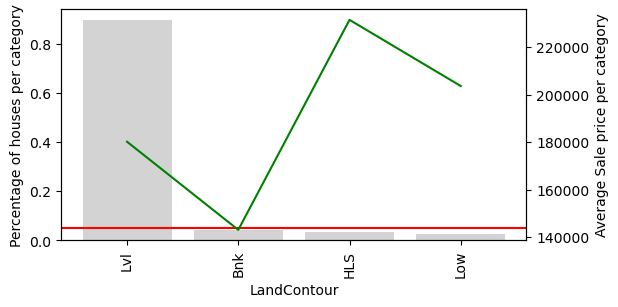

In [21]:
feature_to_look('LandContour')

90% имеют ровный уровень.

Как и с признаком выше форма рельефа имеет незначительное влияние на цену, т.к. менее пригодный для строительтва рельеф не показатель низкой или высокой стоимости.

  Utilities  count_houses  perc_houses      SalePrice
0    AllPub          1458     0.999315  180973.899863
1    NoSeWa             1     0.000685  137500.000000

0.0% - missing value.


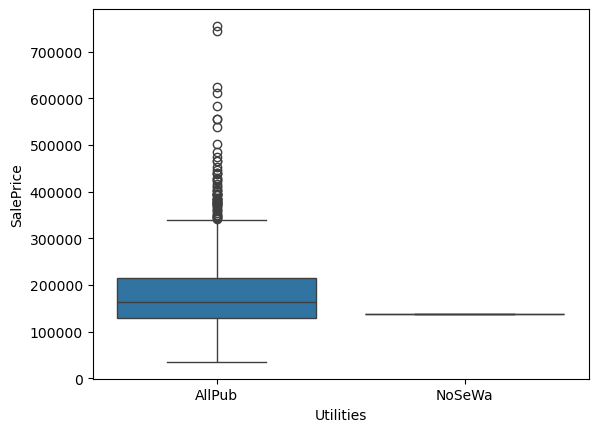

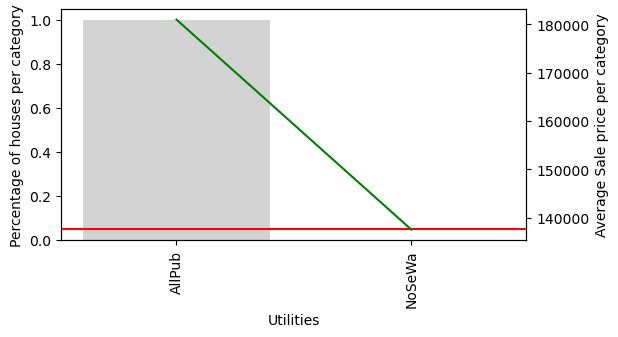

In [22]:
feature_to_look('Utilities')

In [23]:
# посмотрим на дом
data[data['Utilities'] == 'NoSeWa']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
945,20.0,RL,NaN,14375.0,Pave,NaN,IR1,Lvl,NoSeWa,CulDSac,Gtl,Timber,Norm,Norm,1Fam,SLvl,6.0,6.0,1958.0,1958.0,Gable,CompShg,HdBoard,HdBoard,BrkFace,541.0,TA,TA,CBlock,TA,TA,No,GLQ,111.0,Rec,354.0,354.0,819.0,GasA,Gd,Y,FuseA,1344.0,0.0,0.0,1344.0,0.0,1.0,1.0,0.0,3.0,1.0,Gd,7.0,Typ,1.0,Gd,Basment,1958.0,RFn,2.0,525.0,TA,TA,Y,0.0,118.0,0.0,0.0,233.0,0.0,NaN,NaN,NaN,0.0,1.0,2009.0,COD,Abnorml,137500.0


Это действительно уникальный дом в датасете, у которого Utilities = NoSeWa, т.е. отсутствует централизованное водоснабжение и канализация.

Находится в районе Timber — пригород с более "природным" окружением.

Условия продажи — Abnorml (возможно, наследство, банкротство и т.п.), что может объяснять такие необычные условия.

Несмотря на отсутствие инфраструктуры, цена дома не самая низкая — $137,500, вероятно из-за района, общей площади и состояния дома.

Как признак для модели не несет никакой значимости

  LotConfig  count_houses  perc_houses      SalePrice
0    Inside          1051     0.720356  176966.057088
1    Corner           263     0.180260  181623.425856
2   CulDSac            94     0.064428  223854.617021
3       FR2            47     0.032214  177934.574468
4       FR3             4     0.002742  208475.000000

0.0% - missing value.


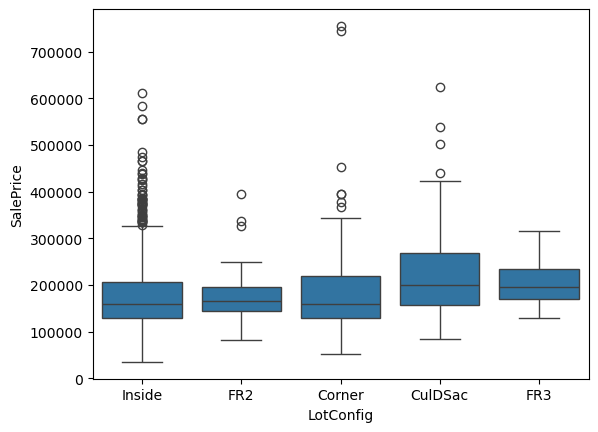

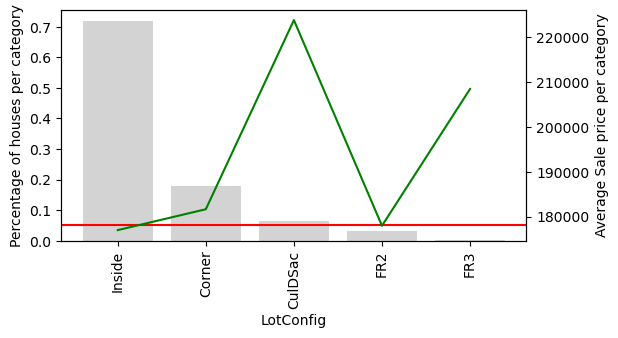

In [24]:
feature_to_look('LotConfig')

CulDSac — самая высокая медиана, среди категорий.

Вероятно связано с тихим расположением, меньшим трафиком и более престижной планировкой.

Общая картина не отражает сильной зависимости цены от расположения относительно соседних домов.

  LandSlope  count_houses  perc_houses      SalePrice
0       Gtl          1381     0.946539  179980.301955
1       Mod            65     0.044551  196734.138462
2       Sev            13     0.008910  204379.230769

0.0% - missing value.


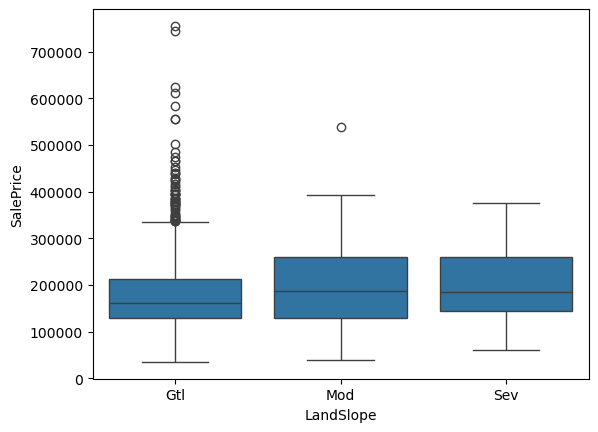

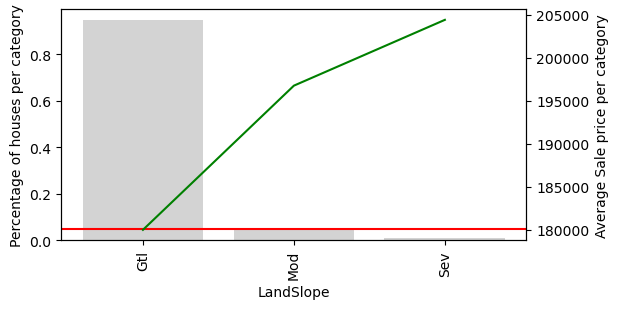

In [25]:
feature_to_look('LandSlope')

Имеется связь логическая связь с признаками LotShape и LandContour. Но не отражает дубликат значений.
- LotShape - Геометрия (план участка)
- LandContour - Высота.
- LandSlope - Уклон участка.
Дополняют друг друга, но имеют склонность к мультиколлинеарности.
С учетом редких лейблов переменная имеет нпизкую значимость в формировании цены.

   Neighborhood  count_houses  perc_houses      SalePrice
0         NAmes           225     0.154215  145847.080000
1       CollgCr           150     0.102810  197965.773333
2       OldTown           113     0.077450  128225.300885
3       Edwards            99     0.067855  128024.949495
4       Somerst            86     0.058944  225379.837209
5       Gilbert            79     0.054147  192854.506329
6       NridgHt            77     0.052776  316270.623377
7        Sawyer            74     0.050720  136793.135135
8        NWAmes            73     0.050034  189050.068493
9       SawyerW            59     0.040439  186555.796610
10      BrkSide            58     0.039753  124834.051724
11      Crawfor            51     0.034955  210624.725490
12      Mitchel            49     0.033585  156270.122449
13      NoRidge            41     0.028101  335295.317073
14       Timber            38     0.026045  242247.447368
15       IDOTRR            37     0.025360  100123.783784
16      ClearC

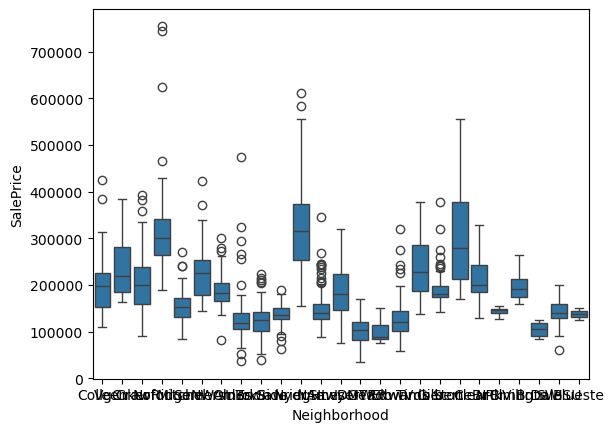

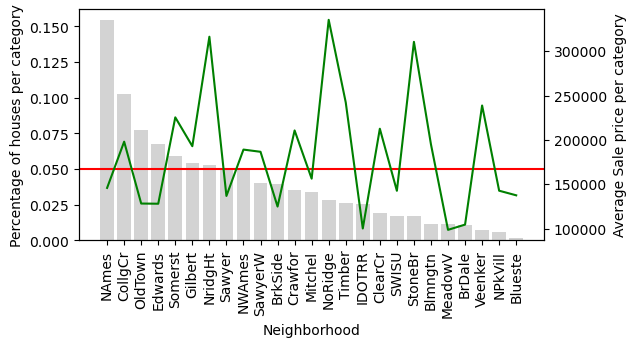

In [26]:
feature_to_look('Neighborhood')

Наблюдается сильный разброс среднего значения. 

Расположение имеет роль в формировании цены.

К примеру дома в элитных районах близ Ada Hyaden Heritage Park имеют высокую стоимость, вне зависимости от факторов препятсвующим стандартному процессу строительства.

Так же могут иметь одинаковую площадь, но более высокую стоимость

В обучении модели будет иметь высокую значимость.

  Condition1  count_houses  perc_houses      SalePrice
0       Norm          1259     0.862920  184524.876886
1      Feedr            81     0.055517  142475.481481
2     Artery            48     0.032899  135091.666667
3       RRAn            26     0.017820  184396.615385
4       PosN            19     0.013023  215184.210526
5       RRAe            11     0.007539  138400.000000
6       PosA             8     0.005483  225875.000000
7       RRNn             5     0.003427  212400.000000
8       RRNe             2     0.001371  190750.000000

0.0% - missing value.


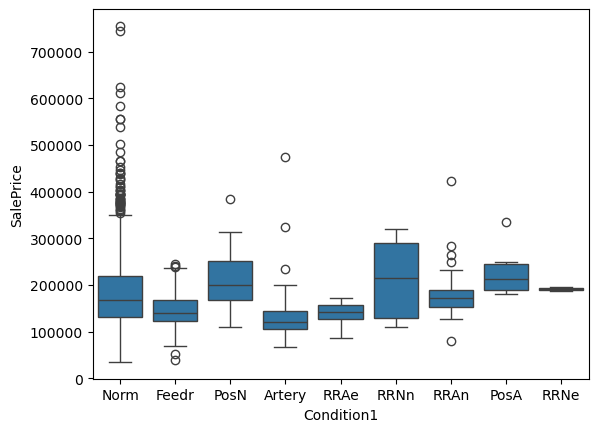

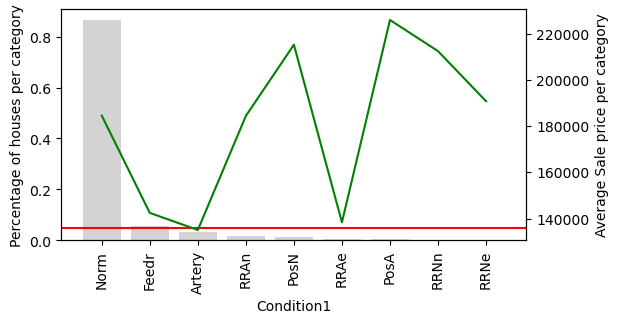

In [27]:
feature_to_look('Condition1')

  Condition2  count_houses  perc_houses      SalePrice
0       Norm          1444     0.989719  181192.722299
1      Feedr             6     0.004112  121166.666667
2     Artery             2     0.001371  106500.000000
3       RRNn             2     0.001371   96750.000000
4       PosN             2     0.001371  284875.000000
5       PosA             1     0.000685  325000.000000
6       RRAn             1     0.000685  136905.000000
7       RRAe             1     0.000685  190000.000000

0.0% - missing value.


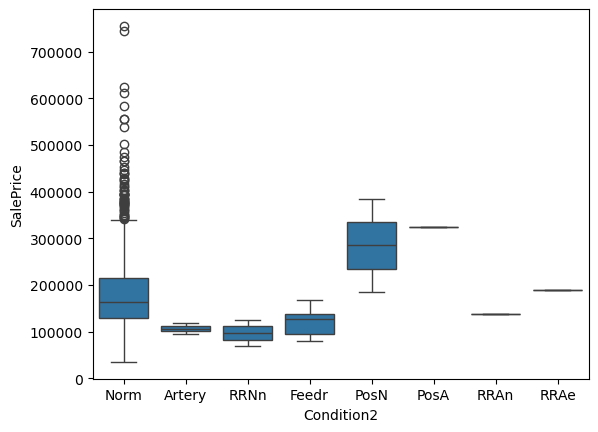

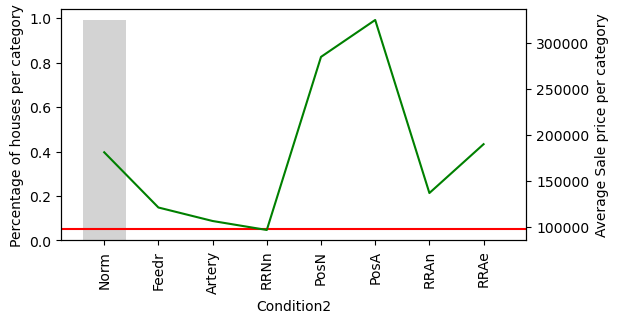

In [28]:
feature_to_look('Condition2')

Из графиков видно что расположение дома близ главной дороги или железной дороги пагубно влияет на формирование цены. 

Высокий шум ведет к падению цены на дом.

При этом 86% домов имеют обычное расположение. Можно объединить лейблы указываюзие на близость дороги.

Дома близ зеленых зон имеют более высокие цены, что указывает на значимость расположения.

В случае с Condition2 почти 99% домов не имеют второстепенное окруюение. Признак можно исключить.

  BldgType  count_houses  perc_houses      SalePrice
0     1Fam          1219     0.835504  185795.196883
1   TwnhsE           114     0.078136  181959.342105
2   Duplex            52     0.035641  133541.076923
3    Twnhs            43     0.029472  135911.627907
4   2fmCon            31     0.021247  128432.258065

0.0% - missing value.


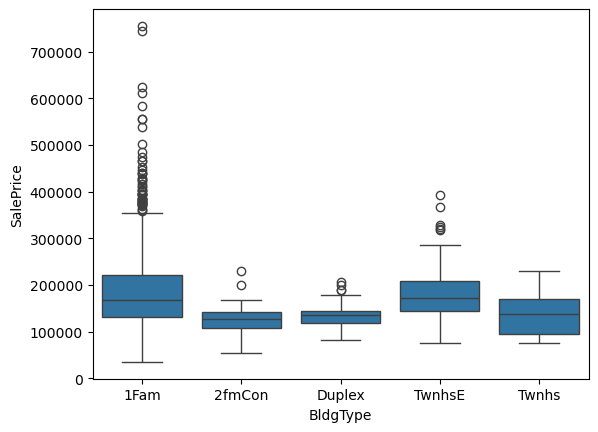

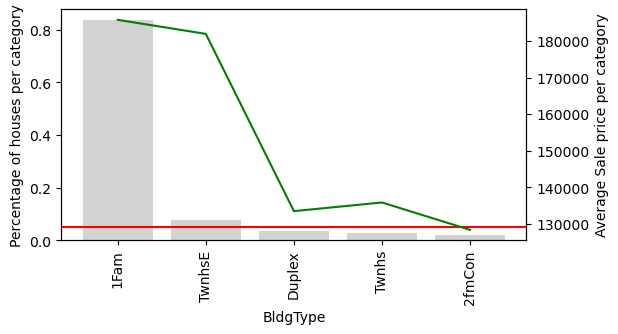

In [29]:
feature_to_look('BldgType')

Из графиков видно что уровень приватности постройки (наличие соседей) ведет к падению цены.

Можно сократить размерность по наличию соседей.

  HouseStyle  count_houses  perc_houses      SalePrice
0     1Story           725     0.496916  176024.768276
1     2Story           445     0.305003  210051.764045
2     1.5Fin           154     0.105552  143116.740260
3       SLvl            65     0.044551  166703.384615
4     SFoyer            37     0.025360  135074.486486
5     1.5Unf            14     0.009596  110150.000000
6     2.5Unf            11     0.007539  157354.545455
7     2.5Fin             8     0.005483  220000.000000

0.0% - missing value.


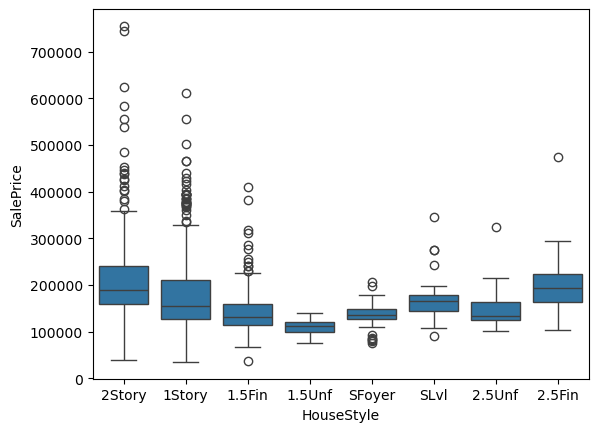

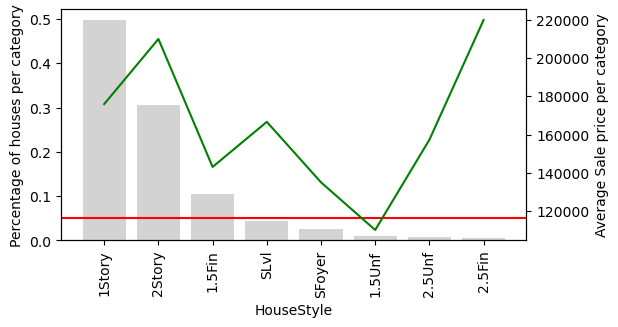

In [30]:
feature_to_look('HouseStyle')

Ахитектурный стиль, количество и целостность этажей ведет к увеличению цены.

  RoofStyle  count_houses  perc_houses      SalePrice
0     Gable          1140     0.781357  171504.994737
1       Hip           286     0.196025  218876.933566
2      Flat            13     0.008910  194690.000000
3   Gambrel            11     0.007539  148909.090909
4   Mansard             7     0.004798  180568.428571
5      Shed             2     0.001371  225000.000000

0.0% - missing value.


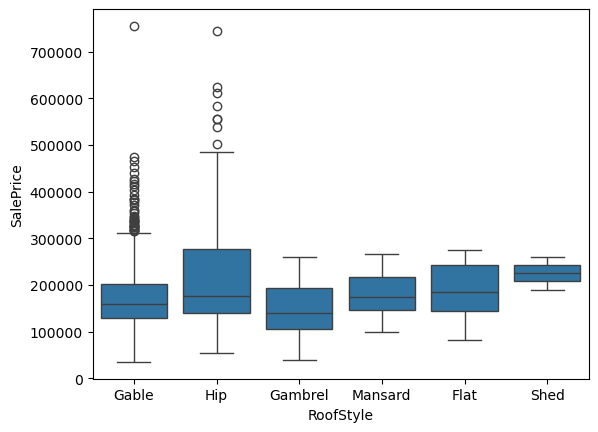

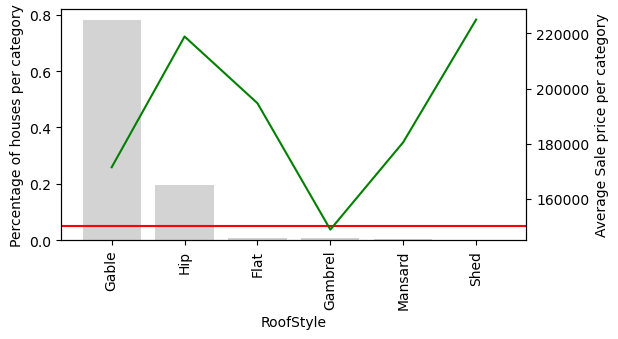

In [31]:
feature_to_look('RoofStyle')

Тип крыши имеет значение при формировании цены, учитывая затраты на строительство.

При этом среднее значение цены имеет не сильный разброс.

Предположительно не сильно влияет на производительность модели, относительно других признаков.

  RoofMatl  count_houses  perc_houses      SalePrice
0  CompShg          1433     0.982180  179826.221912
1  Tar&Grv            11     0.007539  185406.363636
2  WdShngl             6     0.004112  390250.000000
3  WdShake             5     0.003427  241400.000000
4    Metal             1     0.000685  180000.000000
5  Membran             1     0.000685  241500.000000
6     Roll             1     0.000685  137000.000000
7  ClyTile             1     0.000685  160000.000000

0.0% - missing value.


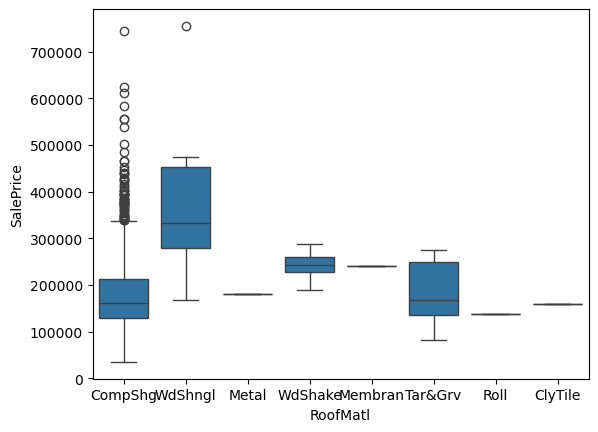

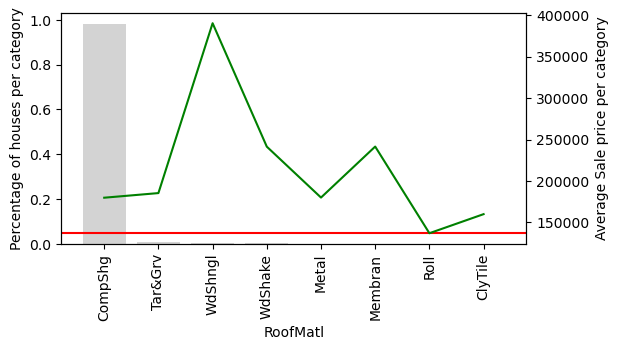

In [32]:
feature_to_look('RoofMatl')

In [33]:
data[data['RoofMatl'] == 'WdShngl']

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
54,20.0,RL,68.0,50271.0,Pave,NaN,IR1,Low,AllPub,Inside,Gtl,Veenker,Norm,Norm,1Fam,1Story,9.0,5.0,1981.0,1987.0,Gable,WdShngl,WdShing,Wd Shng,NaN,0.0,Gd,TA,CBlock,Ex,TA,Gd,GLQ,1810.0,Unf,0.0,32.0,1842.0,GasA,Gd,Y,SBrkr,1842.0,0.0,0.0,1842.0,2.0,0.0,0.0,1.0,0.0,1.0,Gd,5.0,Typ,1.0,Gd,Attchd,1981.0,Fin,3.0,894.0,TA,TA,Y,857.0,72.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,11.0,2006.0,WD,Normal,385000.0
186,75.0,RM,90.0,22950.0,Pave,NaN,IR2,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,2.5Fin,10.0,9.0,1892.0,1993.0,Gable,WdShngl,Wd Sdng,Wd Sdng,NaN,0.0,Gd,Gd,BrkTil,TA,TA,Mn,Unf,0.0,Unf,0.0,1107.0,1107.0,GasA,Ex,Y,SBrkr,1518.0,1518.0,572.0,3608.0,0.0,0.0,2.0,1.0,4.0,1.0,Ex,12.0,Typ,2.0,TA,Detchd,1993.0,Unf,3.0,840.0,Ex,TA,Y,0.0,260.0,0.0,0.0,410.0,0.0,NaN,GdPrv,NaN,0.0,6.0,2006.0,WD,Normal,475000.0
452,20.0,RL,62.0,70761.0,Pave,NaN,IR1,Low,AllPub,Inside,Mod,ClearCr,Norm,Norm,1Fam,1Story,7.0,5.0,1975.0,1975.0,Gable,WdShngl,Plywood,Plywood,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,655.0,Unf,0.0,878.0,1533.0,GasA,TA,Y,SBrkr,1533.0,0.0,0.0,1533.0,1.0,0.0,2.0,0.0,2.0,1.0,Gd,5.0,Typ,2.0,TA,Attchd,1975.0,Unf,2.0,576.0,TA,TA,Y,200.0,54.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,12.0,2006.0,WD,Normal,280000.0
630,80.0,RL,82.0,9020.0,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Feedr,Norm,1Fam,SLvl,6.0,5.0,1964.0,1964.0,Gable,WdShngl,Plywood,Wd Sdng,BrkFace,259.0,TA,TA,CBlock,TA,TA,Gd,GLQ,624.0,Rec,336.0,288.0,1248.0,GasA,TA,Y,SBrkr,1350.0,0.0,0.0,1350.0,1.0,0.0,1.0,1.0,3.0,1.0,TA,6.0,Typ,0.0,NaN,Attchd,1964.0,RFn,2.0,520.0,TA,TA,Y,176.0,0.0,0.0,0.0,0.0,0.0,NaN,GdPrv,NaN,0.0,6.0,2008.0,WD,Normal,168500.0
692,60.0,RL,104.0,21535.0,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NoRidge,Norm,Norm,1Fam,2Story,10.0,6.0,1994.0,1995.0,Gable,WdShngl,HdBoard,HdBoard,BrkFace,1170.0,Ex,TA,PConc,Ex,TA,Gd,GLQ,1455.0,Unf,0.0,989.0,2444.0,GasA,Ex,Y,SBrkr,2444.0,1872.0,0.0,4316.0,0.0,1.0,3.0,1.0,4.0,1.0,Ex,10.0,Typ,2.0,Ex,Attchd,1994.0,Fin,3.0,832.0,TA,TA,Y,382.0,50.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,1.0,2007.0,WD,Normal,755000.0
1045,20.0,RL,80.0,9600.0,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,PosN,Norm,1Fam,1Story,8.0,5.0,1981.0,1981.0,Hip,WdShngl,BrkFace,BrkFace,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,1104.0,Unf,0.0,1420.0,2524.0,GasA,TA,Y,SBrkr,2524.0,0.0,0.0,2524.0,1.0,0.0,2.0,1.0,4.0,1.0,Gd,9.0,Typ,1.0,Gd,Attchd,1981.0,Fin,2.0,542.0,TA,TA,Y,474.0,120.0,0.0,0.0,0.0,0.0,NaN,MnPrv,NaN,0.0,7.0,2009.0,WD,Normal,278000.0


In [34]:
data[data['RoofMatl'] == 'WdShngl'][['Neighborhood','GarageArea', 'GrLivArea', 'SalePrice']]

,Neighborhood,GarageArea,GrLivArea,SalePrice
54,Veenker,894.0,1842.0,385000.0
186,OldTown,840.0,3608.0,475000.0
452,ClearCr,576.0,1533.0,280000.0
630,NAmes,520.0,1350.0,168500.0
692,NoRidge,832.0,4316.0,755000.0
1045,NWAmes,542.0,2524.0,278000.0


98% домов имеют тип - CompShg (Обычная битумная черепица)

При этом материал цены не сильно влияет на цену, если учитывать GarageArea, GrLivArea, не смотря на район.

Что говорит о не высокой значимости материала.

   Exterior1st  count_houses  perc_houses      SalePrice
0      VinylSd           515     0.352981  213732.900971
1      HdBoard           221     0.151474  163147.936652
2      MetalSd           220     0.150788  149422.177273
3      Wd Sdng           206     0.141193  149841.645631
4      Plywood           108     0.074023  175942.379630
5      CemntBd            61     0.041809  231690.655738
6      BrkFace            50     0.034270  194573.000000
7      WdShing            26     0.017820  150655.076923
8       Stucco            25     0.017135  162990.000000
9      AsbShng            20     0.013708  107385.550000
10     BrkComm             2     0.001371   71000.000000
11       Stone             2     0.001371  258500.000000
12     AsphShn             1     0.000685  100000.000000
13     ImStucc             1     0.000685  262000.000000
14      CBlock             1     0.000685  105000.000000

0.0% - missing value.


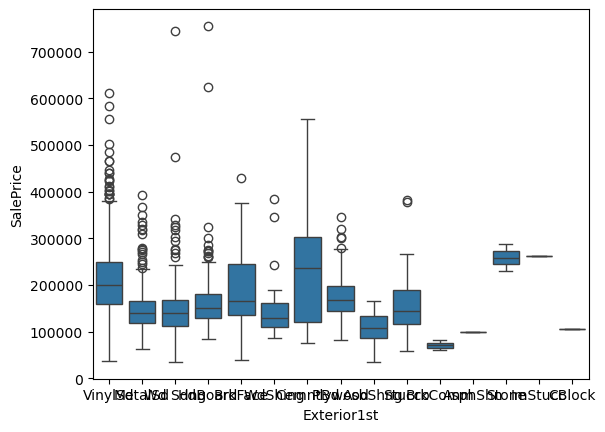

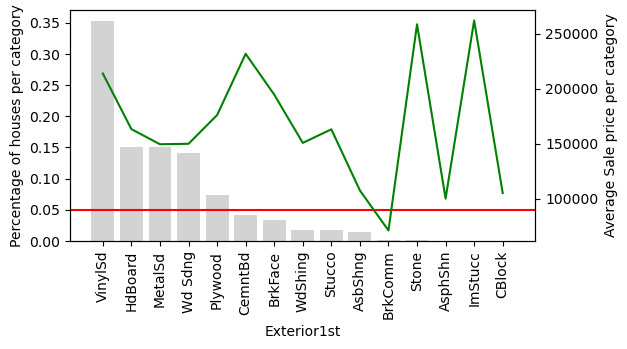

In [35]:
feature_to_look('Exterior1st')

   Exterior2nd  count_houses  perc_houses      SalePrice
0      VinylSd           504     0.345442  214432.460317
1      MetalSd           214     0.146676  149803.172897
2      HdBoard           206     0.141193  167759.436893
3      Wd Sdng           197     0.135024  148386.065990
4      Plywood           142     0.097327  168112.387324
5      CmentBd            60     0.041124  230093.833333
6      Wd Shng            38     0.026045  161328.947368
7       Stucco            26     0.017820  155905.153846
8      BrkFace            25     0.017135  195818.000000
9      AsbShng            20     0.013708  114060.550000
10     ImStucc            10     0.006854  252070.000000
11     Brk Cmn             7     0.004798  126714.285714
12       Stone             5     0.003427  158224.800000
13     AsphShn             3     0.002056  138000.000000
14       Other             1     0.000685  319000.000000
15      CBlock             1     0.000685  105000.000000

0.0% - missing value.


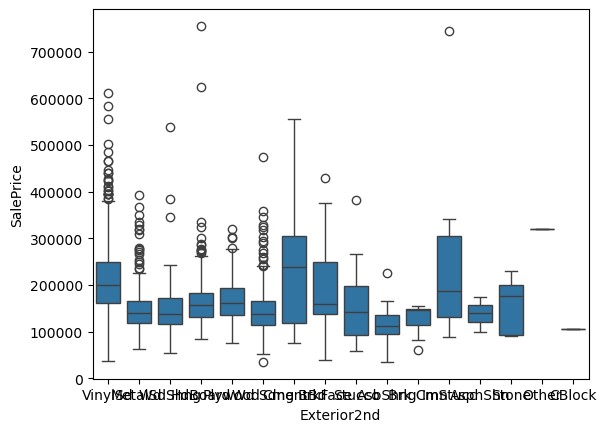

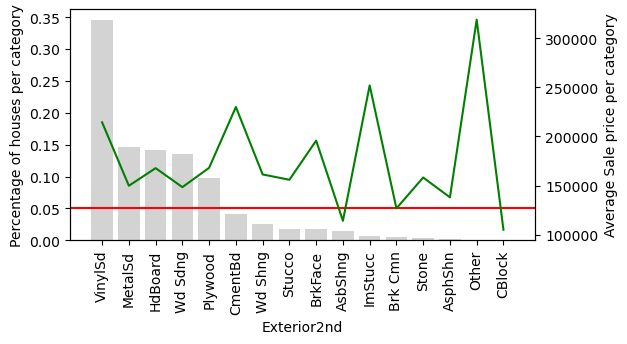

In [36]:
feature_to_look('Exterior2nd')

У основной части домов внешний материал как основной так и вторичный совпадают.

In [37]:
data[data['Exterior1st'] == 'ImStucc'][['Neighborhood','GarageArea', 'GrLivArea', 'SalePrice']]

,Neighborhood,GarageArea,GrLivArea,SalePrice
1188,NoRidge,757.0,1624.0,262000.0


In [38]:
data[data['Exterior2nd'] == 'ImStucc'][['Neighborhood','GarageArea', 'GrLivArea', 'SalePrice']]

,Neighborhood,GarageArea,GrLivArea,SalePrice
275,Mitchel,264.0,816.0,124500.0
285,SawyerW,529.0,1575.0,179200.0
359,ClearCr,288.0,1352.0,130000.0
656,BrDale,264.0,1092.0,88000.0
719,NoRidge,983.0,2418.0,341000.0
780,Mitchel,504.0,1004.0,135000.0
933,Somerst,788.0,1905.0,320000.0
1139,Mitchel,714.0,1567.0,196000.0
1183,NoRidge,813.0,4476.0,745000.0
1188,NoRidge,757.0,1624.0,262000.0


Цена во многом зависит от площади дома, и затратов на кол-во материала, нежели от типа материала.

  MasVnrType  count_houses  perc_houses      SalePrice
0  no_option           871     0.596984  156969.102181
1    BrkFace           445     0.305003  204691.871910
2      Stone           128     0.087731  265583.625000
3     BrkCmn            15     0.010281  146318.066667

0.0% - missing value.


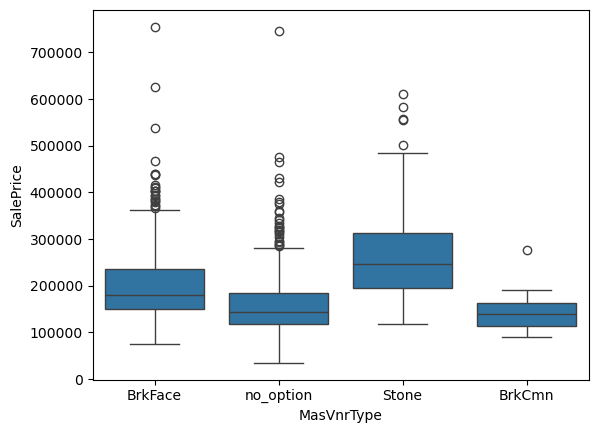

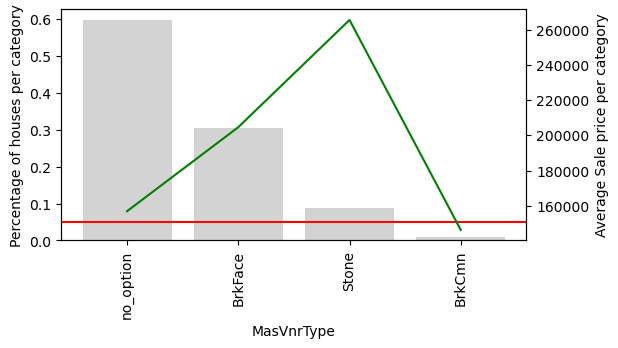

In [39]:
feature_to_look('MasVnrType')

Тип покрытия дома имеет прямое влияние на рост цены в зависимости от типа материала (качества материала) или отсутствия кладки.

Отсутствие облицовки приравнивается к облицовке из обычного кирпича - материал используемый в строительсве, без дополнительного покрытия. 

Можно объединить no_option и BrkCmn.

  ExterQual  count_houses  perc_houses      SalePrice
0        TA           906     0.620973  144341.313466
1        Gd           487     0.333790  231806.268994
2        Ex            52     0.035641  367360.961538
3        Fa            14     0.009596   87985.214286

0.0% - missing value.


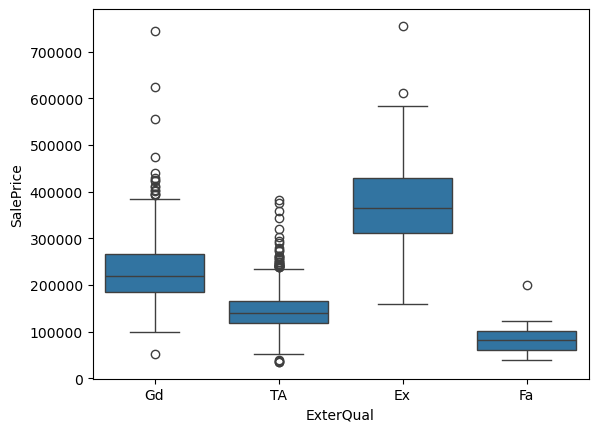

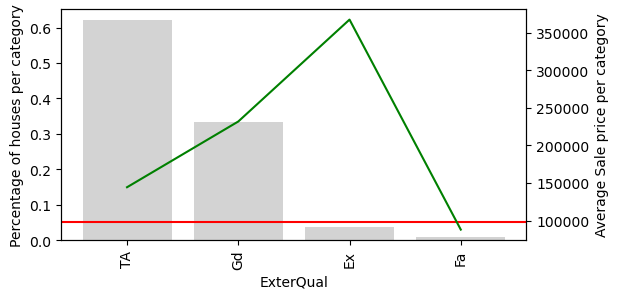

In [40]:
feature_to_look('ExterQual')

Показатель общего качества внешнего материала имеет сильное влияние на цену дома.

Виден сильный разброс среднего значения в зависимости от уровня материалов.

При этом цена имеет линейную зависимость. Выге качество, выше цена.

In [41]:
data[data['ExterQual'] == 'Fa'][['Neighborhood','GarageArea', 'GrLivArea', 'SalePrice']]

,Neighborhood,GarageArea,GrLivArea,SalePrice
53,IDOTRR,516.0,816.0,110000.0
89,IDOTRR,0.0,1526.0,85000.0
342,SawyerW,294.0,841.0,82000.0
376,Edwards,0.0,904.0,61000.0
534,BrkSide,0.0,334.0,39300.0
636,SWISU,0.0,3395.0,200000.0
637,BrkSide,0.0,800.0,60000.0
706,IDOTRR,0.0,1092.0,55000.0
813,IDOTRR,504.0,1044.0,55993.0
822,OldTown,576.0,936.0,93000.0


  ExterCond  count_houses  perc_houses      SalePrice
0        TA          1281     0.877999  184063.416862
1        Gd           146     0.100069  168897.568493
2        Fa            28     0.019191  102595.142857
3        Ex             3     0.002056  201333.333333
4        Po             1     0.000685   76500.000000

0.0% - missing value.


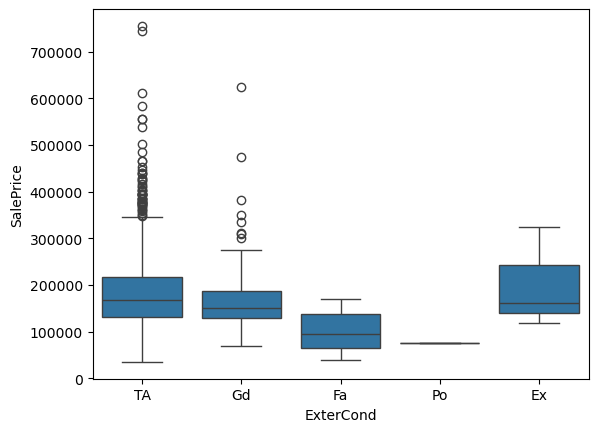

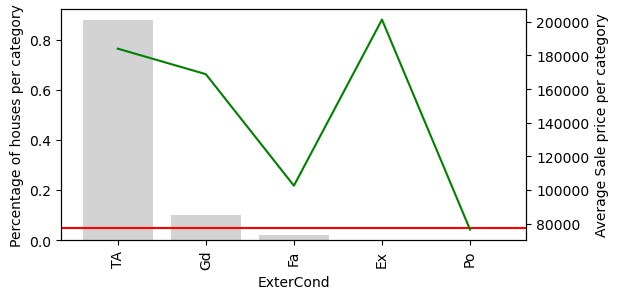

In [42]:
feature_to_look('ExterCond')

97% домов в 2х группах, имеют хорошее и обычное состояние покрытия.

Не сильный разброс средней цены между группами. 

Не имеет потенциально сильного влияния на производительность модели учитывая что состояние почти у всех домов одинаковое.

Качество материала важнее.

  Foundation  count_houses  perc_houses      SalePrice
0      PConc           647     0.443454  225230.442040
1     CBlock           633     0.433859  149809.357030
2     BrkTil           146     0.100069  132291.075342
3       Slab            24     0.016450  107365.625000
4      Stone             6     0.004112  165959.166667
5       Wood             3     0.002056  185666.666667

0.0% - missing value.


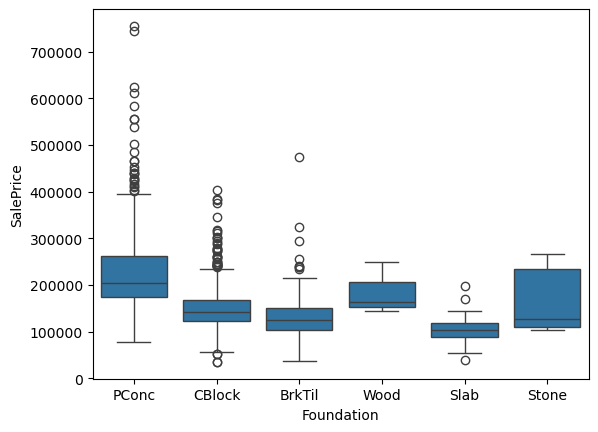

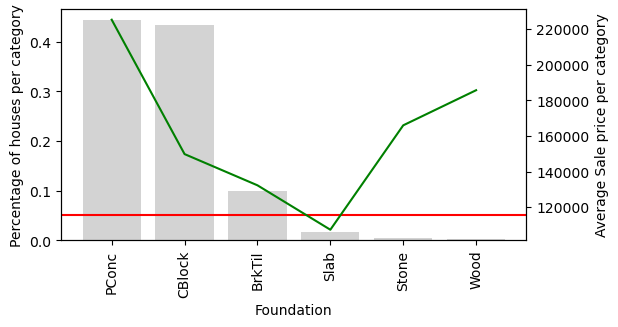

In [43]:
feature_to_look('Foundation')

Цена напрямую зависит от типа фундамента. 

Так как разные фундаменты обеспечивают разные уровни прочности, долговечности и устойчивости к климатическим условиям.

In [44]:
data[data['Foundation'] == 'Wood'][['Neighborhood','GrLivArea', 'SalePrice']]

,Neighborhood,GrLivArea,SalePrice
6,Mitchel,1362.0,143000.0
1181,Timber,2514.0,250000.0
1212,Gilbert,1752.0,164000.0


Высокая цена дома с покрытием 'Wood' обусловленна в большей степени площадью.

Можем удалить редкие лейблы.

    BsmtQual  count_houses  perc_houses      SalePrice
0         TA           648     0.444140  140749.416667
1         Gd           618     0.423578  202688.478964
2         Ex           121     0.082934  327041.041322
3  no_option            37     0.025360  105652.891892
4         Fa            35     0.023989  115692.028571

0.0% - missing value.


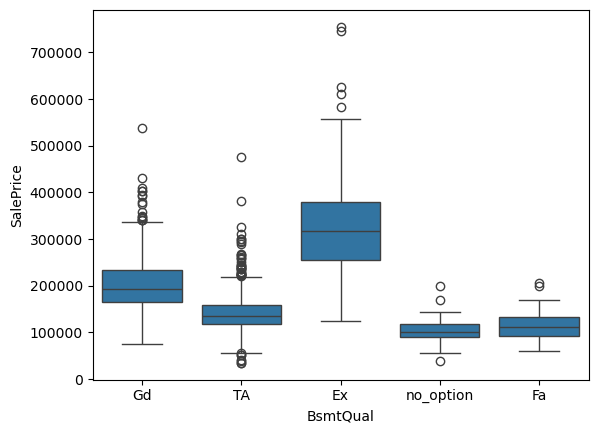

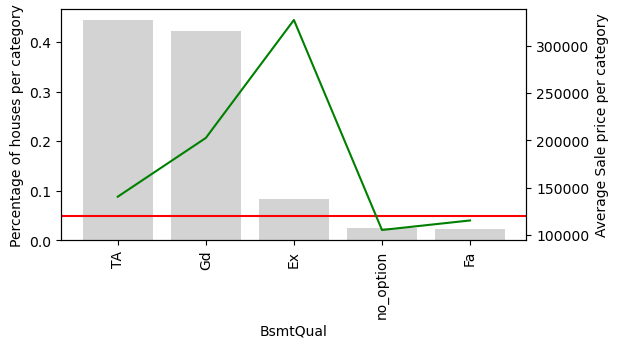

In [45]:
feature_to_look('BsmtQual')

Качество подвала имеет сильную предиктивную силу.

Цена дома существенно меняется в зависимости от качества.

Fa и no_option имеют одинаковую значимость. Говорит о том что подвал не используется, если качество низкое.

Можно объединить в одну группу.

    BsmtCond  count_houses  perc_houses      SalePrice
0         TA          1310     0.897875  183660.203053
1         Gd            65     0.044551  213599.907692
2         Fa            45     0.030843  121809.533333
3  no_option            37     0.025360  105652.891892
4         Po             2     0.001371   64000.000000

0.0% - missing value.


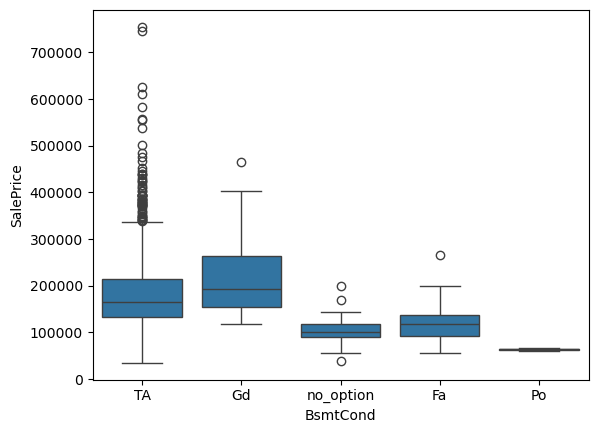

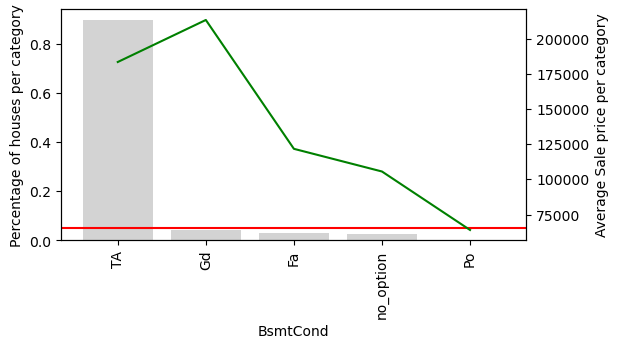

In [46]:
feature_to_look('BsmtCond')

95% подвалов имеют оценку состояния обычно ил хорошо.

Можно не использовать в модели, так как есть признак BsmtQual-качество подвала, который в большей степени определяет цену.

  BsmtExposure  count_houses  perc_houses      SalePrice
0           No           952     0.652502  165671.363445
1           Av           221     0.151474  206643.420814
2           Gd           134     0.091844  257689.805970
3           Mn           114     0.078136  192789.657895
4    no_option            38     0.026045  107938.342105

0.0% - missing value.


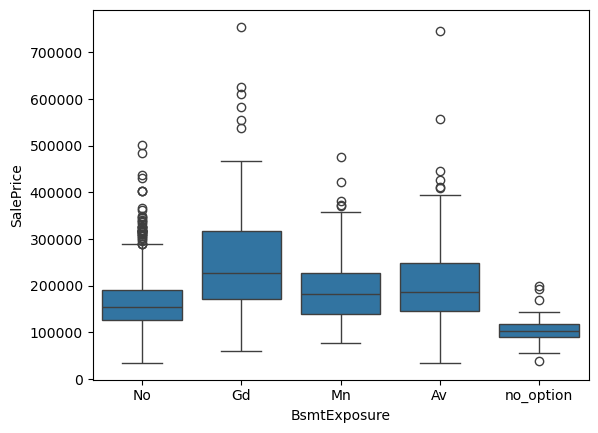

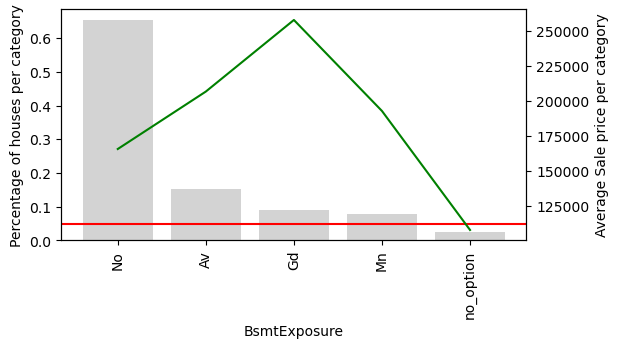

In [47]:
feature_to_look('BsmtExposure')

Степень естественного освещения подвала может влиять на стоимость недвижимости.

Поскольку подвалы с окнами и выходами на улицу считаются более функциональными и удобными.

Gd Может повысить стоимость недвижимости, так как делает подвал пригодным для жилья.

  BsmtFinType1  count_houses  perc_houses      SalePrice
0          Unf           430     0.294722  170670.576744
1          GLQ           418     0.286498  235413.720096
2          ALQ           220     0.150788  161573.068182
3          BLQ           147     0.100754  149507.217687
4          Rec           133     0.091158  146889.248120
5          LwQ            74     0.050720  151852.702703
6    no_option            37     0.025360  105652.891892

0.0% - missing value.


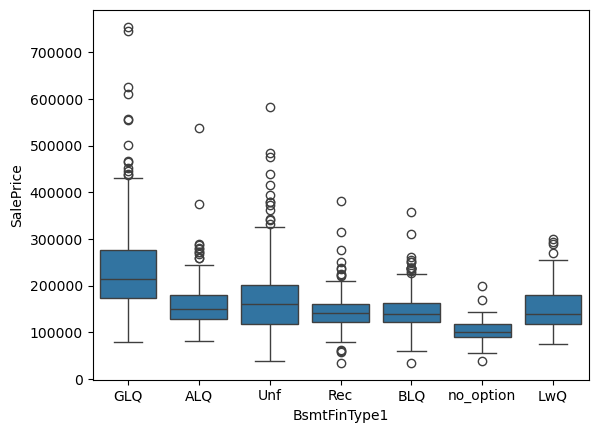

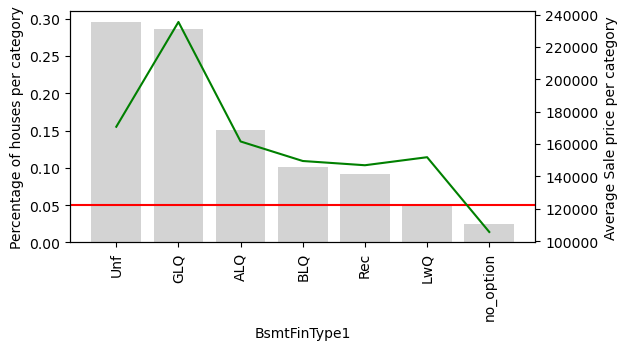

In [48]:
feature_to_look('BsmtFinType1')

По графику видно что тип отделки подвала не имеет особой значимости и среднее значение цены одинаковое.

Исключение GLQ - высокая цена обусловленна тем что площадь используется как полноценное жилое.

  BsmtFinType2  count_houses  perc_houses      SalePrice
0          Unf          1256     0.860864  184694.690287
1          Rec            54     0.037012  164917.129630
2          LwQ            45     0.030843  164738.888889
3    no_option            38     0.026045  110346.236842
4          BLQ            33     0.022618  151101.000000
5          ALQ            19     0.013023  209942.105263
6          GLQ            14     0.009596  180982.142857

0.0% - missing value.


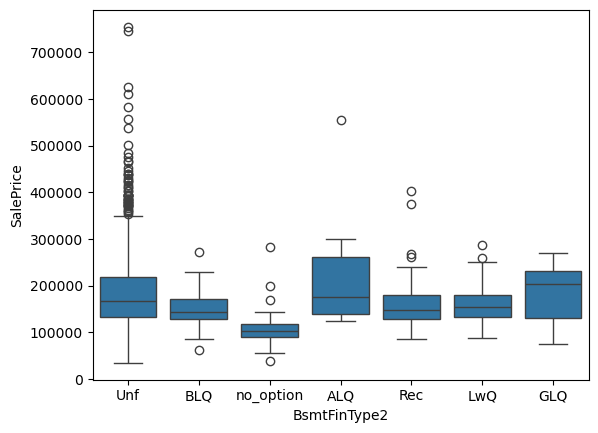

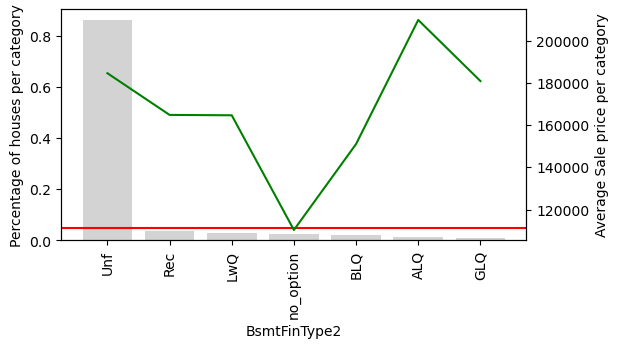

In [49]:
feature_to_look('BsmtFinType2')

In [50]:
(data[(data["BsmtFinType1"] == "GLQ") & (data["SalePrice"] > 180000)][["GrLivArea", "SalePrice"]]).head(40)

,GrLivArea,SalePrice
1,1710.0,208500.0
3,1786.0,223500.0
5,2198.0,250000.0
7,1694.0,307000.0
12,2324.0,345000.0
28,1704.0,306000.0
35,1561.0,277500.0
46,1752.0,319900.0
47,2149.0,239686.0
48,1656.0,249700.0


Можно исключить переменные так как повышение цены обусловленно в большей степени не качеством отделки, а расширением жилой площади.

  Heating  count_houses  perc_houses      SalePrice
0    GasA          1427     0.978067  182045.386826
1    GasW            18     0.012337  166632.166667
2    Grav             7     0.004798   75271.428571
3    Wall             4     0.002742   92100.000000
4    OthW             2     0.001371  125750.000000
5   Floor             1     0.000685   72500.000000

0.0% - missing value.


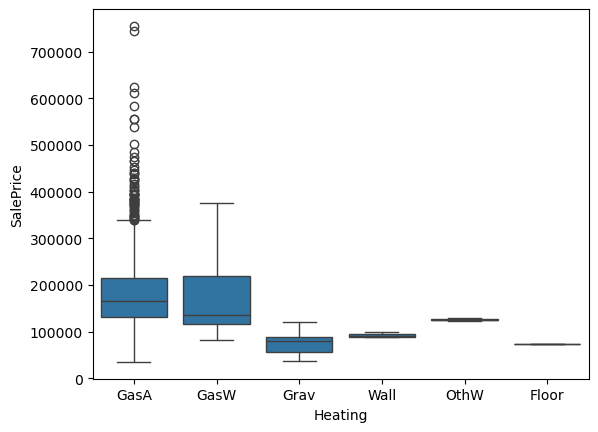

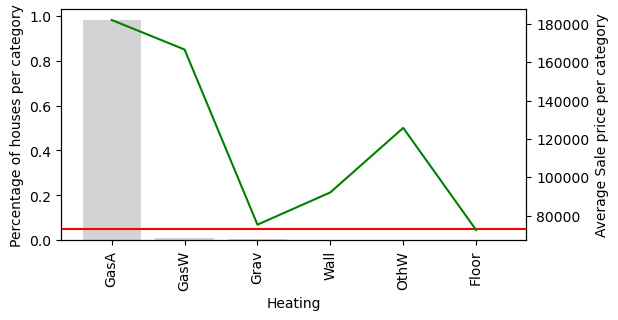

In [51]:
feature_to_look('Heating')

99% домов имеют газовое отопление.

Можно исключить по принципу константы.

  HeatingQC  count_houses  perc_houses      SalePrice
0        Ex           741     0.507882  214914.429150
1        TA           428     0.293352  142362.876168
2        Gd           240     0.164496  156897.866667
3        Fa            49     0.033585  123919.489796
4        Po             1     0.000685   87000.000000

0.0% - missing value.


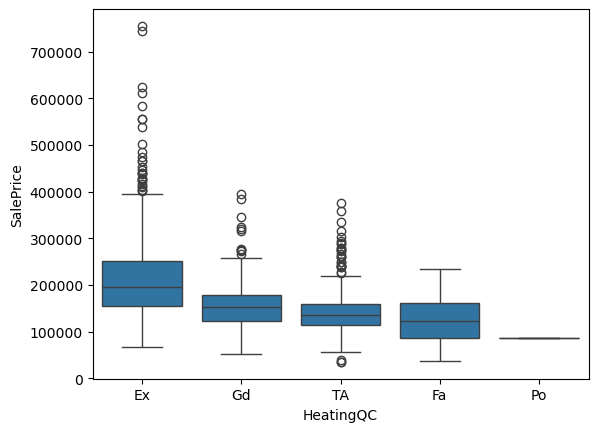

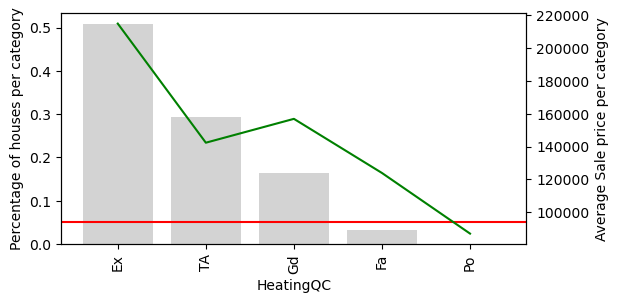

In [52]:
feature_to_look('HeatingQC')

По графику видно что в домах с ценой выше среднего преобладает отличное качество системы отопления.

Качество системы отопления хрошо отражает рост цены.

При этом в редких соучаях мы видим что высокая цена может быть и в домах со средним качеством, что говорит о том что цена обусловлена не качеством системы отопления, а иными признаками.


  CentralAir  count_houses  perc_houses      SalePrice
0          Y          1364     0.934887  186215.072581
1          N            95     0.065113  105264.073684

0.0% - missing value.


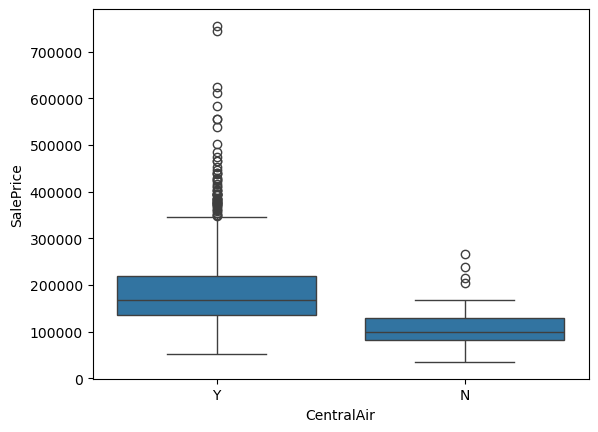

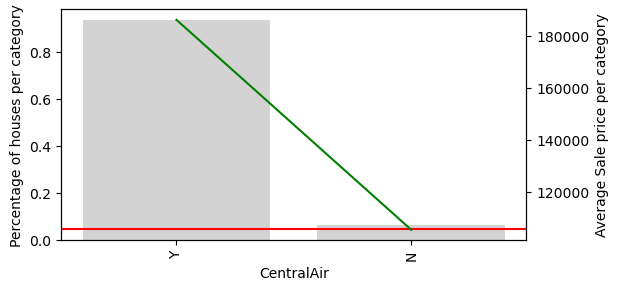

In [53]:
feature_to_look('CentralAir')

Отсутствие центрального кондиционирования может значительно понизить цену дома.

In [54]:
data[(data["CentralAir"] == "N") & (data["SalePrice"] > 150000)][["GrLivArea",'Neighborhood', "SalePrice"]]

,GrLivArea,Neighborhood,SalePrice
276,1548.0,BrkSide,205000.0
329,2134.0,BrkSide,214500.0
418,2624.0,Crawfor,239000.0
489,2414.0,OldTown,160000.0
736,1768.0,OldTown,163000.0
748,2640.0,OldTown,265979.0
975,2019.0,BrkSide,167500.0
1394,1912.0,OldTown,163000.0


  Electrical  count_houses  perc_houses      SalePrice
0      SBrkr          1333     0.913639  186854.614404
1      FuseA            94     0.064428  122196.893617
2      FuseF            27     0.018506  107675.444444
3      FuseP             3     0.002056   97333.333333
4        Mix             1     0.000685   67000.000000
5  no_option             1     0.000685  167500.000000

0.0% - missing value.


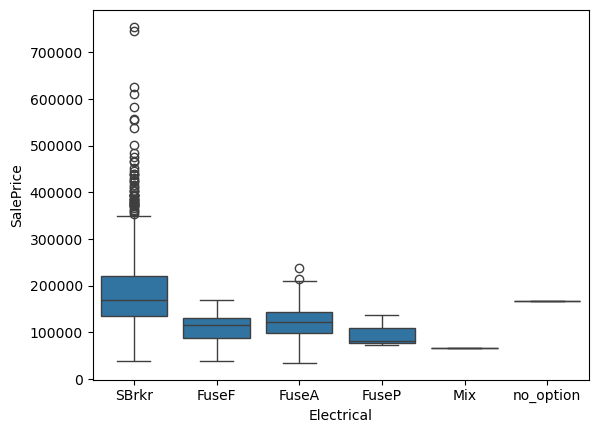

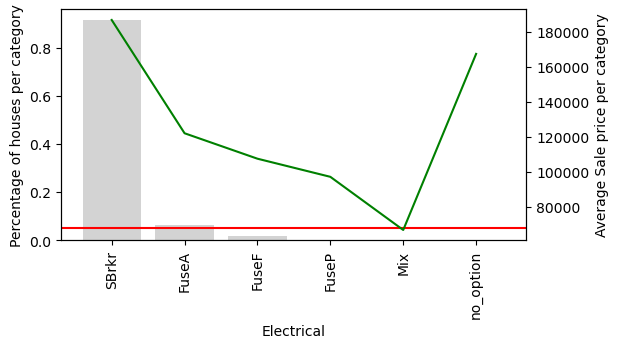

In [55]:
feature_to_look('Electrical')

91% домов имеют современную систему электрики.

8% домов имеют старые вариации систем, что приводит к значительному снижению стоимости.

Может указывать на возраст дома.

In [56]:
(data[data['Electrical'] == 'SBrkr']['YearBuilt']).describe()

count    1333.000000
mean     1974.439610
std        29.134131
min      1872.000000
25%      1958.000000
50%      1977.000000
75%      2002.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [57]:
data[data["Electrical"].isin(["FuseA", "FuseF", 'FuseP'])]["YearBuilt"].describe()

count     124.000000
mean     1937.354839
std        18.129701
min      1880.000000
25%      1921.500000
50%      1941.000000
75%      1954.000000
max      1965.000000
Name: YearBuilt, dtype: float64

Возможно имеет низкую предиктивную значисмоть в модели, если учитывать переменную возраста дома.

  KitchenQual  count_houses  perc_houses      SalePrice
0          TA           734     0.503084  139952.242507
1          Gd           586     0.401645  212116.023891
2          Ex           100     0.068540  328554.670000
3          Fa            39     0.026731  105565.205128

0.0% - missing value.


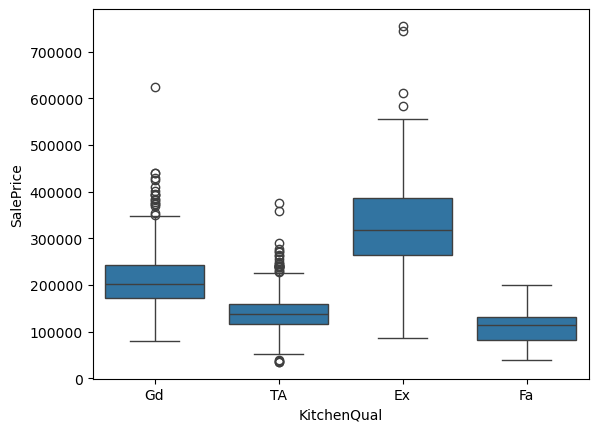

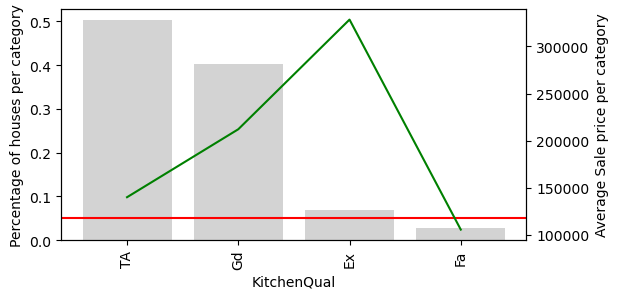

In [58]:
feature_to_look('KitchenQual')

Качество кухни в доме существенно влияет на стоимость недвижимости, поскольку современные и просторные кухни — важный фактор при покупке жилья.

  Functional  count_houses  perc_houses      SalePrice
0        Typ          1359     0.931460  183455.584989
1       Min2            34     0.023304  144240.647059
2       Min1            31     0.021247  146385.483871
3        Mod            15     0.010281  168393.333333
4       Maj1            14     0.009596  153948.142857
5       Maj2             5     0.003427   85800.000000
6        Sev             1     0.000685  129000.000000

0.0% - missing value.


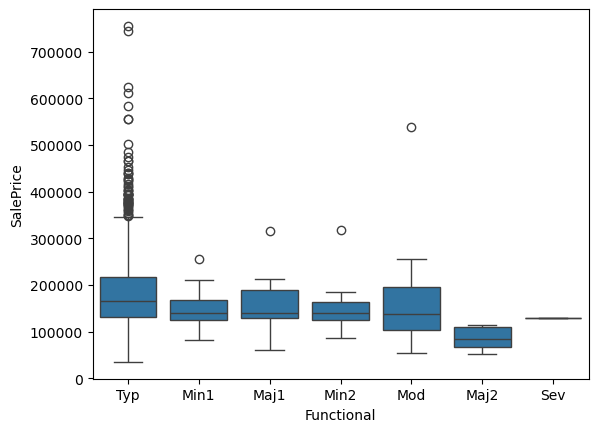

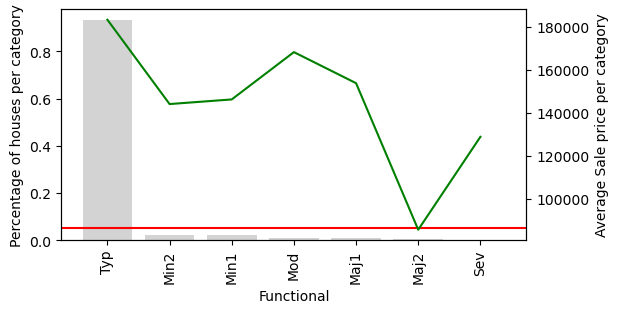

In [59]:
feature_to_look('Functional')

93% домов имеют обычнй тип функциональности и не имеют ограничений или требуют ремонта.

Среднее значение домов с ограничениями вне зависимости от функционала имеют около равное значение.

Высокий процент домов может снизить предиктивную силу признакак в модели.

  FireplaceQu  count_houses  perc_houses      SalePrice
0   no_option           689     0.472241  141322.529753
1          Gd           380     0.260452  226351.415789
2          TA           313     0.214531  205723.488818
3          Fa            33     0.022618  167298.484848
4          Ex            24     0.016450  337712.500000
5          Po            20     0.013708  129764.150000

0.0% - missing value.


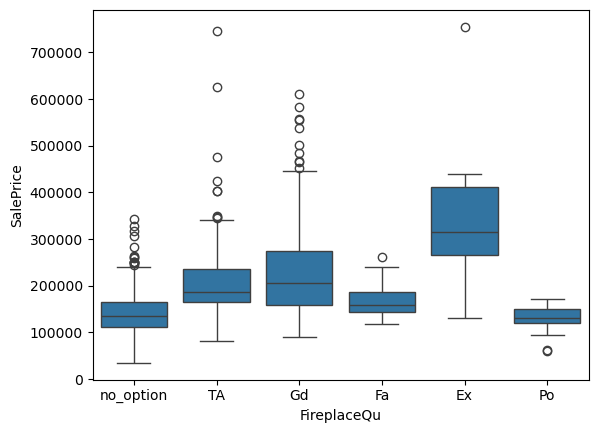

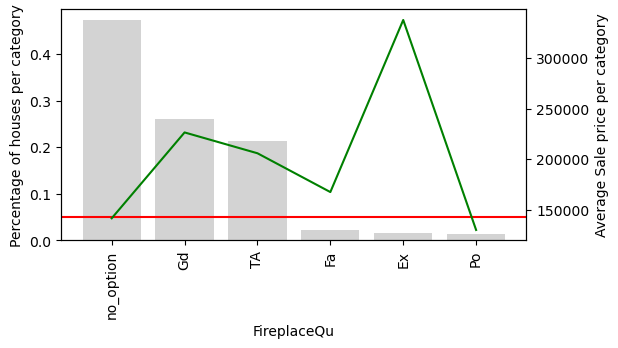

In [60]:
feature_to_look('FireplaceQu')

На графике видно как средний уровень цены на дом меняется в зависимости от качества камина.

Качество камина имеет достаточно сильно влияние на формирование цены.

При этом отсутсвие камина можно приравнять к плохому качеству, так как скорее всего камин не используется по причине неисправности.

  GarageType  count_houses  perc_houses      SalePrice
0     Attchd           869     0.595613  202956.399310
1     Detchd           387     0.265250  134091.162791
2    BuiltIn            88     0.060315  254751.738636
3  no_option            81     0.055517  103317.283951
4    Basment            19     0.013023  160570.684211
5    CarPort             9     0.006169  109962.111111
6     2Types             6     0.004112  151283.333333

0.0% - missing value.


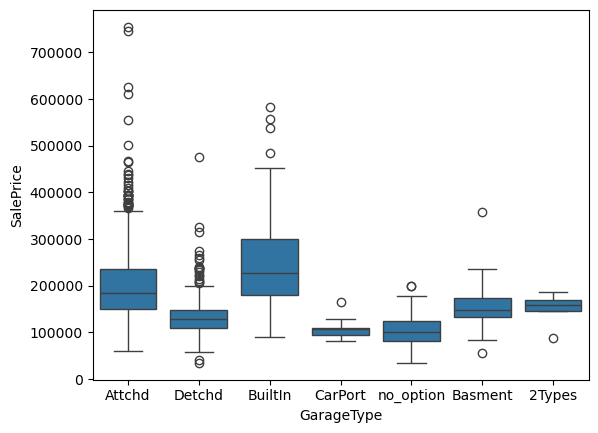

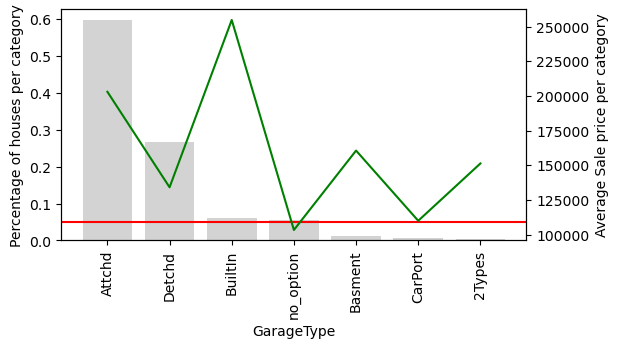

In [61]:
feature_to_look('GarageType')

Тип гаража имеет сушественное влияние на цену, так как наличие удобного гаража повышает привлекательность жилья.

  GarageFinish  count_houses  perc_houses      SalePrice
0          Unf           605     0.414668  142156.423140
1          RFn           422     0.289239  202068.869668
2          Fin           351     0.240576  240316.373219
3    no_option            81     0.055517  103317.283951

0.0% - missing value.


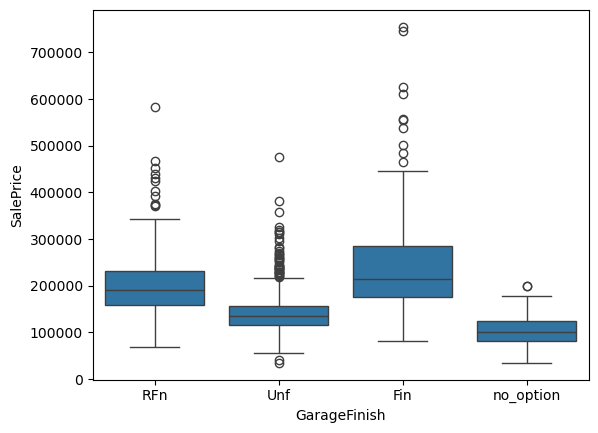

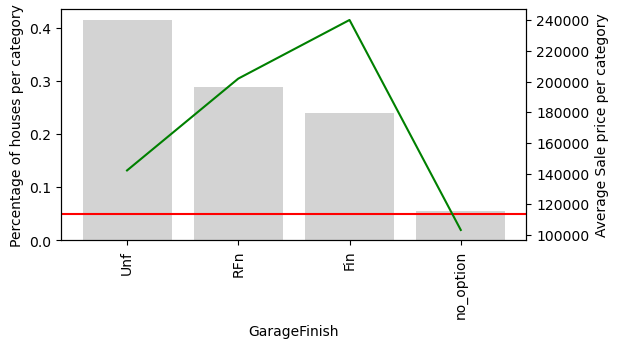

In [62]:
feature_to_look('GarageFinish')

Степень отделки гаража может влиять на стоимость недвижимости, так как качественная отделка делает гараж более удобным и функциональным.

  GarageQual  count_houses  perc_houses      SalePrice
0         TA          1310     0.897875  187520.362595
1  no_option            81     0.055517  103317.283951
2         Fa            48     0.032899  123573.354167
3         Gd            14     0.009596  215860.714286
4         Ex             3     0.002056  241000.000000
5         Po             3     0.002056  100166.666667

0.0% - missing value.


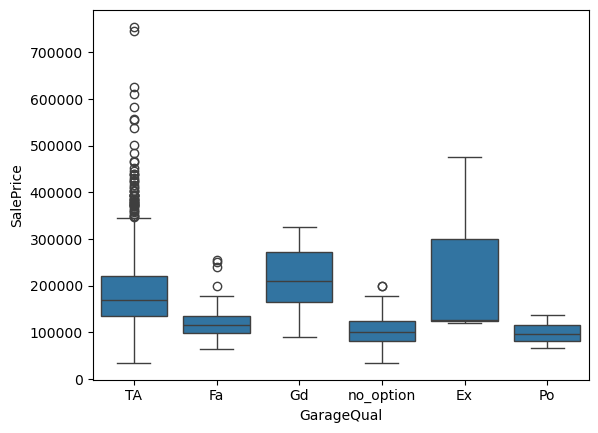

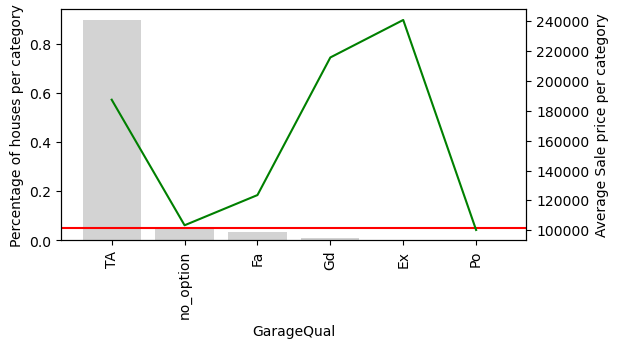

In [63]:
feature_to_look('GarageQual')

Общий показатель качества гаража отражает прямую зависимость цены от уровня.

В то же время 90% имеюь оценку TA - среднюю при высоком разбросе цен.

В данному случае отделка внутренней части гаража GarageFinish отражает более четкую информацию относительно стоимости.

  GarageCond  count_houses  perc_houses      SalePrice
0         TA          1325     0.908156  187916.215094
1  no_option            81     0.055517  103317.283951
2         Fa            35     0.023989  114654.028571
3         Gd             9     0.006169  179930.000000
4         Po             7     0.004798  108500.000000
5         Ex             2     0.001371  124000.000000

0.0% - missing value.


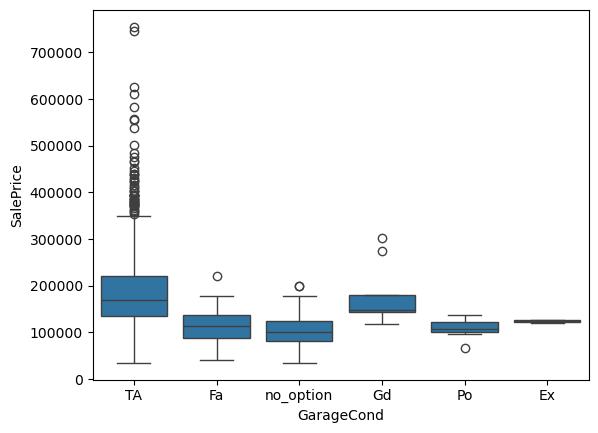

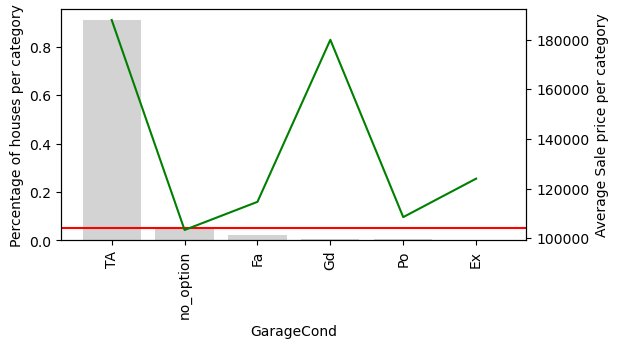

In [64]:
feature_to_look('GarageCond')

91% Имеют общее состояние гаража TA - нормальное. Прослеживается дублирование информации в переменных GarageQual и GarageCond.

Могут иметь низкую предиктивную силу в модели, так как большое количество значений - TA.

  PavedDrive  count_houses  perc_houses      SalePrice
0          Y          1339     0.917752  186463.050784
1          N            90     0.061686  115039.122222
2          P            30     0.020562  132330.000000

0.0% - missing value.


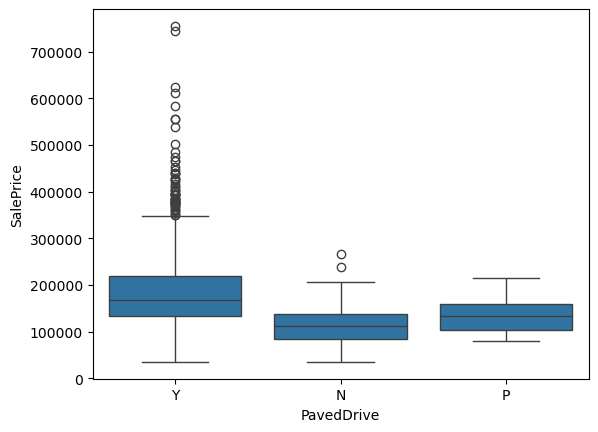

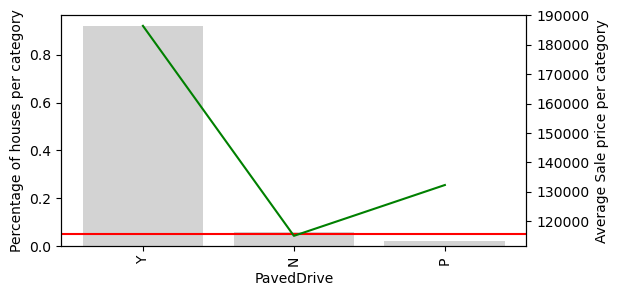

In [65]:
feature_to_look('PavedDrive')

Этот параметр может влиять на удобство использования гаража, его долговечность и стоимость недвижимости.

92% - Y. Среднее значение в классе держится в районе среднего по цене, что говорит о не очень сильном влиянии покрытия на цену дома.

Может иметь низкую силу, учитывая малое количество наблюдений в редких классах.

Может быть хорошо использованна в оценке домов низкого качества, ниже средней цены.

      PoolQC  count_houses  perc_houses      SalePrice
0  no_option          1452     0.995202  180427.325069
1         Gd             3     0.002056  201990.000000
2         Ex             2     0.001371  490000.000000
3         Fa             2     0.001371  215500.000000

0.0% - missing value.


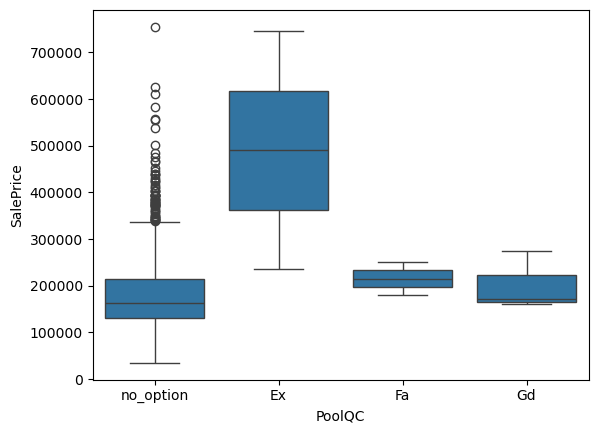

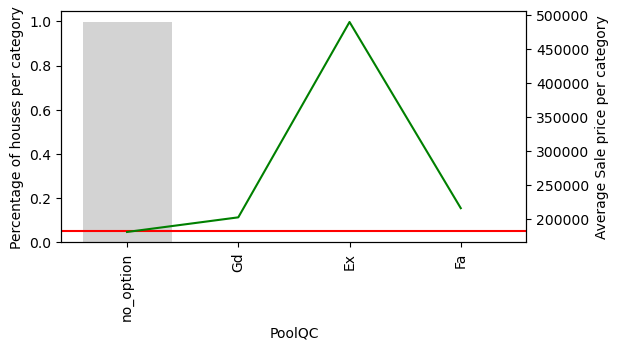

In [66]:
feature_to_look('PoolQC')

Как налчие бассеина так и его качество могут значительно влиять на цену дома.

Но учитывая малое кол-во наблюдений, переменная может негативно сказаться на обучении модели.

       Fence  count_houses  perc_houses      SalePrice
0  no_option          1178     0.807402  187630.876061
1      MnPrv           157     0.107608  148751.089172
2      GdPrv            59     0.040439  178927.457627
3       GdWo            54     0.037012  140379.314815
4       MnWw            11     0.007539  134286.363636

0.0% - missing value.


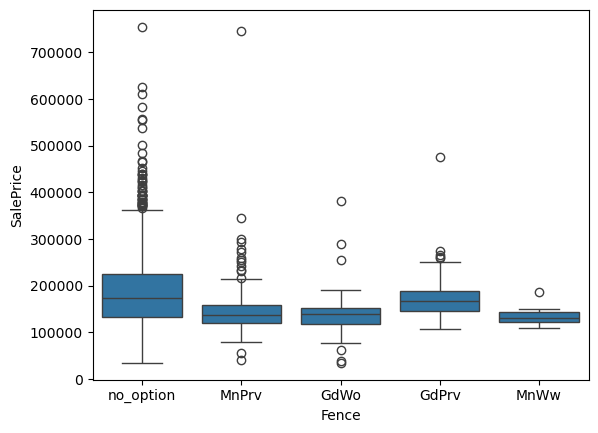

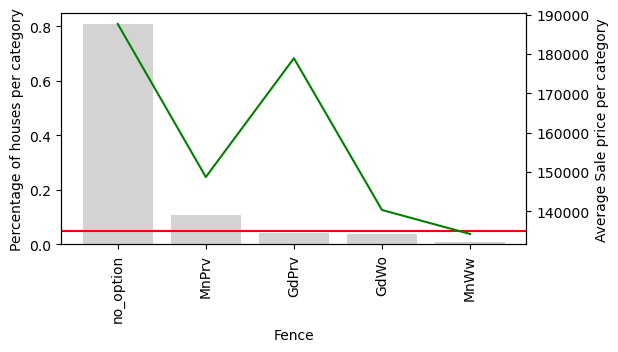

In [67]:
feature_to_look('Fence')

Тип забора на участке, может влиять на стоимость, поскольку добавляет приватности и защищённости.

Предположим что в 81% случаев забор отсутсвует.

При этом ср. цена такого дома близка к ср. цене с домом у которого забор высокого качества.

Самое частое значение - 11% среднее качество. 

При этом цена дома без забора выше цены с забором.

Отражает искаженую ифнормацию зависимости цены.

  MiscFeature  count_houses  perc_houses      SalePrice
0   no_option          1405     0.962988  182070.998577
1        Shed            49     0.033585  151187.612245
2        Gar2             2     0.001371  170750.000000
3        Othr             2     0.001371   94000.000000
4        TenC             1     0.000685  250000.000000

0.0% - missing value.


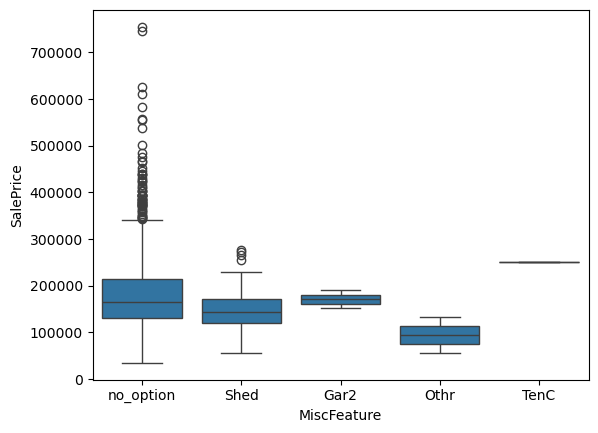

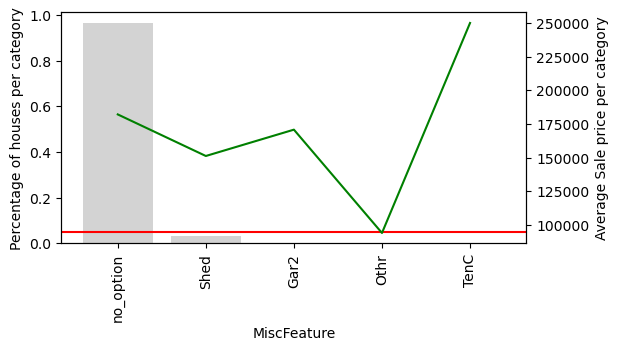

In [68]:
feature_to_look('MiscFeature')

97% домов не имеют дополнительных особенностей.

Особенностей может быть огромное кол-во, в зависимости от того какие аръитектурные решения примет владелец,

что в свою очередь не объективно может сказаться на цене дома.

Может не значительно влиять на модель, а так же снизить качество в связи с малым кол-м наблюдений.

  SaleType  count_houses  perc_houses      SalePrice
0       WD          1266     0.867718  173422.296209
1      New           122     0.083619  274945.418033
2      COD            43     0.029472  143973.255814
3    ConLD             9     0.006169  138780.888889
4    ConLI             5     0.003427  200390.000000
5    ConLw             5     0.003427  143700.000000
6      CWD             4     0.002742  210600.000000
7      Oth             3     0.002056  119850.000000
8      Con             2     0.001371  269600.000000

0.0% - missing value.


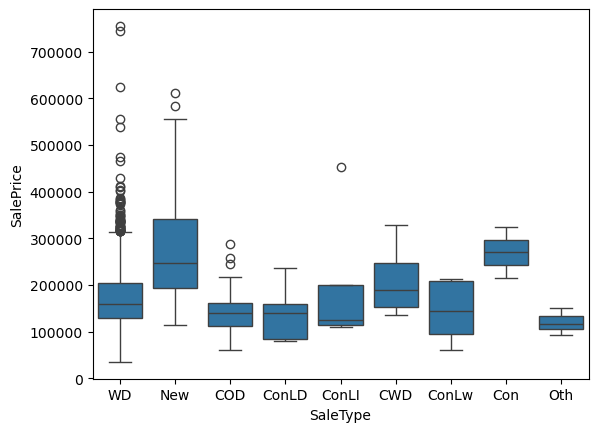

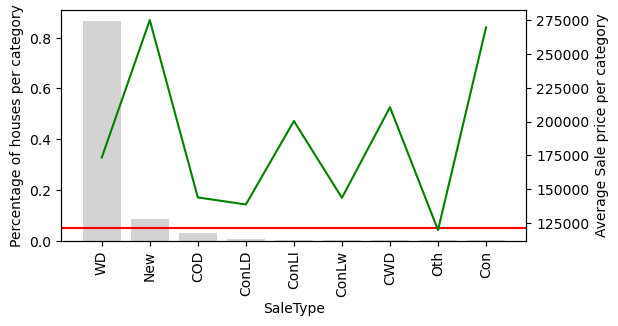

In [69]:
feature_to_look('SaleType')

In [70]:
(data[data['SaleType'] == 'New'][['YearBuilt', 'SalePrice']]).describe()

,YearBuilt,SalePrice
count,122.000000,122.000000
mean,2005.959016,274945.418033
std,7.954829,103239.582158
min,1920.000000,113000.000000
25%,2006.000000,194050.250000
50%,2006.000000,247453.000000
75%,2007.000000,341919.750000
max,2010.000000,611657.000000


Тип продажи может существенно повлиять на стоимость жилья, так как новые дома имеют более высокую стоимость.

Можно использовать в модели на основе типа сделки по новизне дома.

Редкие лейблы можно не учитывать в силу их малого кол-ва.

  SaleCondition  count_houses  perc_houses      SalePrice
0        Normal          1197     0.820425  175225.362573
1       Partial           125     0.085675  272291.752000
2       Abnorml           101     0.069225  146526.623762
3        Family            20     0.013708  149600.000000
4        Alloca            12     0.008225  167377.416667
5       AdjLand             4     0.002742  104125.000000

0.0% - missing value.


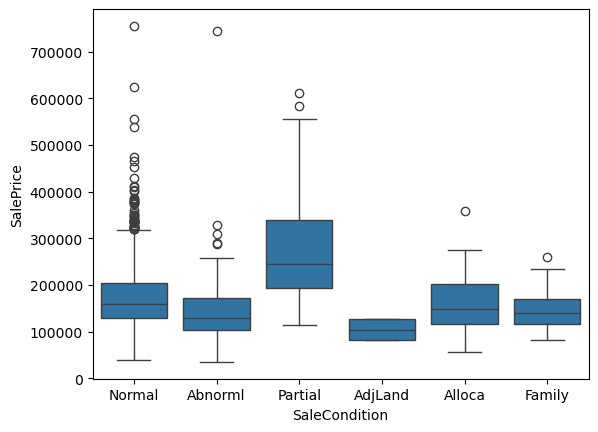

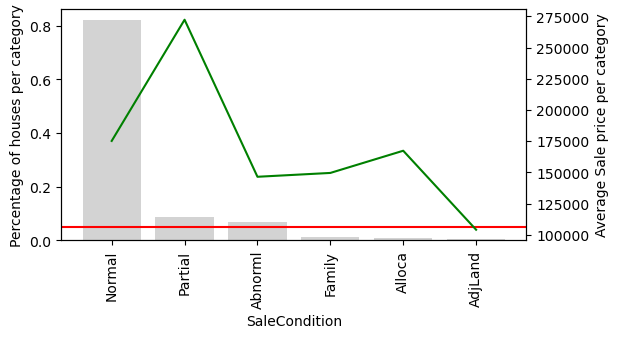

In [71]:
feature_to_look('SaleCondition')

Поскольку разные типы продаж могут подразумевать скидки, ремонты или особые договорённости, признак может иметь высокую значимость.

Имеются сходные показатели с признаком SaleType.

При этом пременая SaleCondition - Условия продажи отражает информацию по формированию цены более точно.

В модели можно исключить признак SaleType в пользу SaleCondition.

Использовать 3 класса, обычная продажа, новый дом, нетипичные условия.

Продажу родственникам можно отнести к нетипичным случаям. Остальные занчения исключить.

# Определим номинальные и ординальные признаки.

In [72]:
cols_to_use = 'MSSubClass', 'OverallQual', 'OverallCond', 'MoSold'
data_num_to_cat = pd.read_csv('../houseprice.csv', usecols=cols_to_use)
data_num_to_cat.nunique()

MSSubClass     15
OverallQual    10
OverallCond     9
MoSold         12
dtype: int64

In [73]:
for var in data_num_to_cat:
    print(var, data_num_to_cat[var].unique()[0:20], '\n')

MSSubClass [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40] 

OverallQual [ 7  6  8  5  9  4 10  3  1  2] 

OverallCond [5 8 6 7 4 2 3 9 1] 

MoSold [ 2  5  9 12 10  8 11  4  1  7  3  6] 



### Категориальные признаки представленные в виде числовых:
||||
|-|-|-|
| MSSubClass  | Тип жилья (например, 20, 60 и т.д.) | Хотя числовой, это категориальный             |
| OverallQual | Общая оценка качества               | Явно порядковый (1–10)                        |
| OverallCond | Общая оценка состояния              | Тоже порядковый (1–10)                        |
| MoSold      | Месяц продажи                       | Можно считать упорядоченной категорией (1–12) |

In [83]:
data_categorical.shape

(1459, 44)

In [80]:
for var in data_categorical:
    print(var, data_categorical[var].unique()[0:20], '\n')

MSZoning ['RL' 'RM' 'C (all)' 'FV' 'RH'] 

Street ['Pave' 'Grvl'] 

Alley ['no_option' 'Grvl' 'Pave'] 

LotShape ['Reg' 'IR1' 'IR2' 'IR3'] 

LandContour ['Lvl' 'Bnk' 'Low' 'HLS'] 

Utilities ['AllPub' 'NoSeWa'] 

LotConfig ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3'] 

LandSlope ['Gtl' 'Mod' 'Sev'] 

Neighborhood ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr'] 

Condition1 ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe'] 

Condition2 ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe'] 

BldgType ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs'] 

HouseStyle ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin'] 

RoofStyle ['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed'] 

RoofMatl ['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile'] 

Exterior1st ['VinylSd' 'MetalSd' 'Wd Sdng'

### Признаки имеющие порядок (ординальные)
||||
|-|-|-|
| OverallQual    | Общая оценка качества дома                | 1 – 10                                       |
| OverallCond    | Общая оценка состояния дома               | 1 – 10                                       |
| MoSold         | Месяц продажи                             | 1-12                                         |
| ExterQual      | Качество внешней отделки                  | Ex, Gd, TA, Fa, Po                           |
| ExterCond      | Состояние внешней отделки                 | Ex, Gd, TA, Fa, Po                           |
| BsmtQual       | Качество подвала                          | Ex, Gd, TA, Fa, Po, None                     |
| BsmtCond       | Состояние подвала                         | Ex, Gd, TA, Fa, Po, None                     |
|BsmtExposure    | Освещеность.                              | No, Gd, Mn, Av                               |
|BsmtFinType1, BsmtFinType2  | Тип отделки.                  | GLQ, ALQ, Unf ,Rec, BLQ, LwQ                 |
| HeatingQC      | Качество отопления                        | Ex, Gd, TA, Fa, Po                           |
| KitchenQual    | Качество кухни                            | Ex, Gd, TA, Fa, Po                           |
| FireplaceQu    | Качество камина                           | Ex, Gd, TA, Fa, Po, None                     |
| GarageFinish   | Степень отделки                           | RFn, Unf, Fin, None                          |
| GarageQual     | Качество гаража                           | Ex, Gd, TA, Fa, Po, None                     |
| GarageCond     | Состояние гаража                          | Ex, Gd, TA, Fa, Po, None                     |
| PoolQC         | Качество бассейна                         | Ex, Gd, TA, Fa, None                         |
| Functional     | Функциональность дома                     | Typ, Min1, Min2, Mod, Maj1, Maj2, Sev, Sal   |
| LandSlope      | Уклон участка                             | Gtl, Mod, Sev                                |
| LotShape       | Форма участка                             | Reg, IR1, IR2, IR3                           |
| PavedDrive     | Асфальтированный ли подъезд               | Y, P, N                                      |
| Fence          | Тип забора                                | GdPrv, MnPrv, GdWo, MnWw, None               |


### Признаки не имеющие порядок (номинальные)

|||
|-|-|
| MSSubClass                 | Тип жилья                                   
| MSZoning                   | Зонирование (RL, RM, C, FV и др.)           
| Street                     | Тип улицы (Grvl, Pave)                      
| Alley                      | Тип переулка                                
| LandContour                | Тип земельного участка                      
| Utilities                  | Тип коммунальных услуг                                      
| LotConfig                  | Конфигурация участка                        
| Neighborhood               | Район                                       
| Condition1, Condition2     | Близость к различным условиям               
| BldgType                   | Тип здания                                  
| HouseStyle                 | Стиль дома                                  
| RoofStyle                  | Тип крыши                                   
| RoofMatl                   | Материал крыши                              
| Exterior1st, Exterior2nd   | Материалы внешней отделки                   
| MasVnrType                 | Тип каменной облицовки                      
| Foundation                 | Тип фундамента                              
| Heating                    | Тип отопления                               
| CentralAir                 | Есть ли центральное кондиционирование (Y/N) 
| Electrical                 | Тип электросистемы                          
| GarageType                 | Тип гаража                                  
| MiscFeature                | Прочие особенности (теннисный корт и др.)   
| SaleType                   | Тип продажи                                 
| SaleCondition              | Условия продажи                             


In [113]:
ordinal_cols = [
    'OverallQual',
    'OverallCond',
    'MoSold',     
    'ExterQual', 
    'ExterCond', 
    'BsmtQual',   
    'BsmtCond',  
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',  
    'KitchenQual',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual', 
    'GarageCond', 
    'PoolQC',     
    'Functional',
    'LandSlope',
    'LotShape',
    'PavedDrive',
    'Fence'
]

nominal_cols = [
    'MSSubClass',
    'MSZoning',
    'Street',
    'Alley',
    'LandContour',
    'Utilities',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',        
    'Foundation',       
    'Heating',           
    'CentralAir',       
    'Electrical',       
    'GarageType',       
    'MiscFeature',      
    'SaleType',         
    'SaleCondition'   
]

In [114]:
len(ordinal_cols), len(nominal_cols)

(22, 25)

In [115]:
data_categorical = pd.read_csv('../houseprice.csv', usecols=ordinal_cols+nominal_cols+['SalePrice'])

### Define categorical variables cardinality

In [116]:
# Checking cardinality
(data_categorical.nunique()).sort_values(ascending=False)

SalePrice        663
Neighborhood      25
Exterior2nd       16
MSSubClass        15
Exterior1st       15
MoSold            12
OverallQual       10
OverallCond        9
Condition1         9
SaleType           9
RoofMatl           8
HouseStyle         8
Condition2         8
Functional         7
RoofStyle          6
Foundation         6
BsmtFinType2       6
Heating            6
GarageType         6
SaleCondition      6
BsmtFinType1       6
GarageQual         5
LotConfig          5
BldgType           5
MSZoning           5
GarageCond         5
FireplaceQu        5
Electrical         5
ExterCond          5
HeatingQC          5
LandContour        4
LotShape           4
MiscFeature        4
KitchenQual        4
Fence              4
BsmtQual           4
ExterQual          4
BsmtExposure       4
BsmtCond           4
LandSlope          3
PavedDrive         3
GarageFinish       3
PoolQC             3
MasVnrType         3
Alley              2
Street             2
Utilities          2
CentralAir   


#### Признаков с высокой кардинальностью не выявлено.


Посмотрим на признак с самым высоким кол-м уникальных значений Neigborhood.

Отсортируем районы по цене.

In [117]:
(calculate_mean_target_per_category(data, 'Neighborhood')).sort_values(ascending=False, by='SalePrice')

,Neighborhood,count_houses,perc_houses,SalePrice
13,NoRidge,41,0.028101,335295.317073
6,NridgHt,77,0.052776,316270.623377
18,StoneBr,25,0.017135,310499.000000
14,Timber,38,0.026045,242247.447368
22,Veenker,11,0.007539,238772.727273
4,Somerst,86,0.058944,225379.837209
16,ClearCr,28,0.019191,212565.428571
11,Crawfor,51,0.034955,210624.725490
1,CollgCr,150,0.102810,197965.773333
19,Blmngtn,17,0.011652,194870.882353


В переменной 'Neighborhood' можно произвести группировку по цене.

- Дорогие. > 300,000.	NoRidge, NridgHt, StoneBr
- Выше среднего. 200,000 – 250,000 - Timber, Veenker, Somerst, ClearCr, Crawfor
- Средний сегмент. 160,000–200,000 - CollgCr, Blmngtn, Gilbert, NWAmes, SawyerW
- Ниже среднего. 130,000–160,000 - Mitchel, NAmes, NPkVill, SWISU, Blueste, Sawyer
- Дешевые. < 130,000 - OldTown, Edwards, BrkSide, BrDale,IDOTRR, MeadowV

In [118]:
neighborhood_ = ((calculate_mean_target_per_category(data, 'Neighborhood')).sort_values(ascending=False, by='SalePrice'))
neighborhood_ = neighborhood_[['Neighborhood','count_houses', 'SalePrice']]

In [1]:
plt.figure(figsize=(20, 10))
sns.scatterplot(data=neighborhood_, x='count_houses', y='SalePrice', hue='Neighborhood', palette='coolwarm')

levels = [130000, 160000, 200000, 250000, 300000]
for level in levels:
    plt.axhline(y=level, color='red', linestyle='--', linewidth=1)
    
plt.yticks(levels)

plt.show()

NameError: name 'plt' is not defined

# Conclusion

### На основе анализа сделаны следующие выводы:

#### Признаки имеющие наибольшее влияние на модель:
- Neigborhood - значимый признак показывающий зависимость цены от района.
- переменные отражающие качество, прослеживается линейный тип связи роста цены (ExterQuall,BsmtQuall, HeatingQC, KitchenQual, FirePlaceQu)
- MasVnrType - материал фассада.
- Foundation - прочный фундамента важный критерий покупки.
- BsmntExposure - дает возможность использовать подвал в качестве жилого, что сильно отражается на цене.
- GarageType, GarageFinish - важная чать дома и имеет высокий вес при формировании цены.
#### Признаки имеющие низкое влияние:
В силу малого кол-ва наблюдений, хоть и некоторые отражают значительное изменение цены.
- Street - 99%
- Alley - 94%
- LandContour - 90%
- Utilities - 1 дом без канализации.
- Landslope - 96%
- Condition1,2 - 99%
- Roofmat - 98%
- ExterCond 97%
- BsmtCond - 95%
- CentralAir - 93%
- Exterial - 91%
- Functional - 93%
- GarageQual, GarageCond - 90%. Оценка качества и состояния гаража не отражается на цене, как его тип и отделка.
- PaveDrive - 92%
- PoolQC - 99% Отсутвует басеин.
- MiscFuture - 97%
- Heating - 99%

#### Fence - Отражает информацию не корректно. Высота не показатель роста цены.

#### BldgType использовать как бинарный признак по принципу наличия соседей.

#### Neiborhood -  Объединим в группы по престижу.

#### Принято решение заменить пустые значения на 0 или None.

#### Использовать следующие методы кодирования в зависимости от группы (ординальные, номинальные)
- OrdinalEncoder
- OneHotEncoder

#### При формировании датасета для тренировки учесть что MSSubClass, OverallQual, OverallCond, MoSold категориальные переменные.